# 티빙 최종 프로젝트

섹션 순서: **데이터 개요 → 합성 최종데이터 기준 전처리 → EDA → 패널 생성 → 모델링 → 대시보드 산출**

In [1]:
from google.colab import drive  # 구글 드라이브 연동 모듈
drive.mount("/content/drive")  # 드라이브를 작업 환경에 연결

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. 실행 환경 및 경로 설정

In [2]:
from pathlib import Path  # 경로를 객체로 다루기 위한 모듈
import os  # 파일/폴더 제어용 모듈

def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for cand in candidates:
        if (cand / "data").exists():
            return cand
    return start

PROJECT_ROOT = find_repo_root(Path.cwd())  # 현재 작업 기준 프로젝트 루트
DATA_DIR = PROJECT_ROOT / "data"  # 데이터 폴더
OUTPUT_DIR = PROJECT_ROOT / "outputs"  # 결과 저장 폴더
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)  # 폴더가 없으면 생성

# 아래는 주요 입력 데이터 경로를 변수로 정리한 부분
CHURN_FINAL_PATH = DATA_DIR / "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_churn_final.csv"
SEARCH_PATH_DEFAULT = DATA_DIR / "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_search_2025.csv"
RECO_PATH_DEFAULT = DATA_DIR / "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_recommend_2025.csv"
WATCH_PATH_DEFAULT = DATA_DIR / "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_watch_2025.csv"
CATALOG_PATH_DEFAULT = DATA_DIR / "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/content_catalog_2025.csv"

ENRICHED_CHURN_PATH = OUTPUT_DIR / "synthetic_churn_final_enriched.csv"
PANEL_PATH = OUTPUT_DIR / "weekly_snapshot_panel_28d_features_14d_label.csv"
METRICS_PATH = OUTPUT_DIR / "final10_lightgbm_metrics.csv"
DASHBOARD_FULL_PATH = OUTPUT_DIR / "dashboard_results_final10_TypeA.csv"
DASHBOARD_OPS_PATH = OUTPUT_DIR / "dashboard_results_final10_TypeA_ops.csv"
SHAP_GLOBAL_CSV = OUTPUT_DIR / "shap_global_importance.csv"
SHAP_HIGH_RISK_CSV = OUTPUT_DIR / "shap_high_risk_top_reasons.csv"
SHAP_HIGH_RISK_TEXT_CSV = OUTPUT_DIR / "shap_high_risk_top_reasons_with_text.csv"
SHAP_BEESWARM_PNG = OUTPUT_DIR / "shap_beeswarm_global.png"
SHAP_BAR_PNG = OUTPUT_DIR / "shap_bar_global.png"
DASHBOARD_WATCH_DISTRIBUTION_PATH = OUTPUT_DIR / "CHECK_THIS_FILE.csv"

required_files = [
    CHURN_FINAL_PATH, SEARCH_PATH_DEFAULT, RECO_PATH_DEFAULT,
    WATCH_PATH_DEFAULT, CATALOG_PATH_DEFAULT,
]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("다음 필수 파일이 없습니다:\n- " + "\n- ".join(missing))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /content
DATA_DIR: /content/data
OUTPUT_DIR: /content/outputs


## 1. 데이터 개요

In [3]:
import pandas as pd  # CSV 파일을 읽고, 표 형태 데이터(DataFrame)로 다루기 위한 pandas 불러오기

# =========================================================
# 1. 파일 개요(overview) 확인
# =========================================================
# 각 원본/가공 파일이 어디에 있는지 파일명:경로 형태로 정리
# 이후 반복문으로 파일별 행/열 수와 주요 컬럼을 빠르게 점검할 때 사용
overview_files = {  # 파일별 개요 확인용 딕셔너리
    "synthetic_churn_final": CHURN_FINAL_PATH,          # 최종 사용자 단위 churn 분석용 데이터
    "synthetic_search_2025": SEARCH_PATH_DEFAULT,       # 검색 로그 데이터
    "synthetic_recommend_2025": RECO_PATH_DEFAULT,      # 추천 노출/반응 로그 데이터
    "synthetic_watch_2025": WATCH_PATH_DEFAULT,         # 시청 로그 데이터
    "content_catalog_2025": CATALOG_PATH_DEFAULT,       # 콘텐츠 메타데이터(카탈로그)
}

summary_rows = []  # 파일별 요약 정보를 한 줄씩 저장할 리스트

# overview_files에 들어있는 각 파일을 하나씩 읽어서 기본 구조를 확인
for name, path in overview_files.items():  # 파일명(name), 파일경로(path)를 순회
    df = pd.read_csv(path)  # 현재 파일을 DataFrame으로 읽기

    # 파일별 핵심 요약 정보를 딕셔너리 형태로 리스트에 추가
    summary_rows.append({
        "file": name,                               # 파일 이름
        "rows": len(df),                            # 전체 행 수
        "cols": len(df.columns),                    # 전체 컬럼 수
        "sample_columns": ", ".join(df.columns[:8])  # 앞쪽 8개 컬럼명을 문자열로 묶어서 미리보기
    })

# 누적한 요약 리스트를 하나의 표(DataFrame)로 변환
overview_df = pd.DataFrame(summary_rows)

# 노트북 환경에서 표 형태로 깔끔하게 출력
display(overview_df)

print("\nsynthetic_churn_final 주요 컬럼 확인:")

# 최종 churn 데이터는 전체를 다 읽을 필요 없이,
# 상위 3행만 읽어서 컬럼명 구조만 빠르게 확인
base_cols = pd.read_csv(CHURN_FINAL_PATH, nrows=3)

# 컬럼명을 리스트 형태로 출력해서 실제 사용 가능한 변수 확인
print(base_cols.columns.tolist())

# =========================================================
# 1-1. 파일별 QA 점검
# =========================================================
import pandas as pd  # pandas 재호출(중복이어도 실행에는 문제 없음)

# 파일별로 점검할 기준을 미리 정리한 설정표
# - path: 파일 경로
# - required_cols: 최소한 있어야 하는 핵심 컬럼
# - id_cols: 중복 여부를 확인할 식별자 컬럼
# - time_cols: 날짜/시간 범위를 확인할 컬럼
qa_specs = {
    "synthetic_churn_final": {
        "path": CHURN_FINAL_PATH,  # 최종 churn 데이터 경로
        "required_cols": ["user_id", "churn_status"],  # 반드시 있어야 하는 핵심 컬럼
        "id_cols": ["user_id"],  # user 단위 중복 확인용
        "time_cols": ["signup_date", "acct_first_playback_date", "acct_last_playback_date", "first_event_ts"],  # 날짜 범위 확인용 컬럼
    },
    "synthetic_search_2025": {
        "path": SEARCH_PATH_DEFAULT,  # 검색 로그 파일 경로
        "required_cols": ["user_id", "search_id", "timestamp"],  # 검색 로그 핵심 컬럼
        "id_cols": ["search_id"],  # 검색 이벤트 고유 식별자
        "time_cols": ["timestamp"],  # 검색 발생 시각
    },
    "synthetic_recommend_2025": {
        "path": RECO_PATH_DEFAULT,  # 추천 로그 파일 경로
        "required_cols": ["user_id", "recommendation_id", "timestamp"],  # 추천 로그 핵심 컬럼
        "id_cols": ["recommendation_id"],  # 추천 이벤트 고유 식별자
        "time_cols": ["timestamp"],  # 추천 발생 시각
    },
    "synthetic_watch_2025": {
        "path": WATCH_PATH_DEFAULT,  # 시청 로그 파일 경로
        "required_cols": ["user_id", "timestamp"],  # 시청 로그 핵심 컬럼
        "id_cols": ["session_id"],  # 세션 단위 중복 확인용
        "time_cols": ["timestamp"],  # 시청 발생 시각
    },
    "content_catalog_2025": {
        "path": CATALOG_PATH_DEFAULT,  # 콘텐츠 카탈로그 파일 경로
        "required_cols": ["movie_id"],  # 콘텐츠 식별자 확인
        "id_cols": ["movie_id"],  # movie_id 중복 여부 확인
        "time_cols": [],  # 카탈로그는 시간 컬럼 점검 대상 없음
    },
}

# 개별 파일 하나에 대해 QA를 수행하는 함수
def run_file_qa(name, spec):
    df = pd.read_csv(spec["path"])  # 전달받은 경로의 파일을 읽기

    # 구분선과 함께 현재 어떤 파일을 검사 중인지 출력
    print("\n" + "=" * 70)
    print(f"[QA] {name}")
    print("=" * 70)

    # 데이터의 전체 크기(행, 열) 확인
    print("shape:", df.shape)

    # ---------------------------------------------------------
    # 1) 필수 컬럼 결측 확인
    # ---------------------------------------------------------
    # required_cols 중 실제 데이터에 존재하는 컬럼만 골라냄
    # (컬럼이 아예 없을 경우 에러 방지)
    existing_required = [c for c in spec["required_cols"] if c in df.columns]

    if existing_required:
        print("\n[필수 컬럼 결측]")

        # 필수 컬럼별 결측치 개수 출력
        # user_id, churn_status, timestamp 같은 핵심값이 비어있는지 확인 가능
        print(df[existing_required].isna().sum())

    # ---------------------------------------------------------
    # 2) ID 컬럼 중복 확인
    # ---------------------------------------------------------
    # id_cols 중 실제 존재하는 컬럼만 대상으로 중복 여부 확인
    existing_ids = [c for c in spec["id_cols"] if c in df.columns]

    if existing_ids:
        print("\n[ID 중복]")

        # 각 ID 컬럼별로 duplicated() 개수를 세어서 중복 건수 출력
        for col in existing_ids:
            print(f"{col} duplicated:", int(df[col].duplicated().sum()))

    # ---------------------------------------------------------
    # 3) 시간 컬럼 범위 확인
    # ---------------------------------------------------------
    # time_cols 중 실제 존재하는 컬럼만 대상으로 날짜 파싱 후 최소/최대 범위를 점검
    existing_time_cols = [c for c in spec["time_cols"] if c in df.columns]

    if existing_time_cols:
        print("\n[시간 범위]")

        for col in existing_time_cols:
            # 날짜형으로 안전하게 변환
            # 변환 실패 값은 errors="coerce"로 NaT 처리
            ts = pd.to_datetime(df[col], errors="coerce")

            # 해당 시간 컬럼의 시작 시점, 종료 시점, 변환 실패/결측 건수 출력
            print(f"{col}: {ts.min()} ~ {ts.max()} / null={int(ts.isna().sum())}")

# qa_specs에 정의된 모든 파일에 대해 QA 함수 실행
for name, spec in qa_specs.items():
    run_file_qa(name, spec)

,file,rows,cols,sample_columns
0,synthetic_churn_final,7799,63,"user_id, age, gender, subscription_plan, watch..."
1,synthetic_search_2025,27247,13,"user_id, timestamp, activity_type, device_type..."
2,synthetic_recommend_2025,55671,15,"user_id, timestamp, activity_type, movie_id, d..."
3,synthetic_watch_2025,95879,18,"movie_id, title, title_raw, release_date, user..."
4,content_catalog_2025,1030,6,"movie_id, title_raw, genre_primary, title_tvin..."



synthetic_churn_final 주요 컬럼 확인:
['user_id', 'age', 'gender', 'subscription_plan', 'watch_hours', 'days_since_last_login', 'device', 'monthly_fee', 'churn_status', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre', 'signup_date', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'viewing_time_decline_rate', 'watch_time_7d', 'completion_rate', 'avg_time_per_use', 'early_exit_ratio', 'high_engagement_index', 'inactive_period', 'usage_freq', 'activity_density_7d', 'search_engagement', 'freq_smartphone', 'freq_tv_set', 'genre_concentration_index', 'content_diversity_score', 'post_hook_continuation', 'first_watch_content_48h', 'support_tickets_is_missing', 'payment_failures_is_missing', 'acct_first_playback_date', 'acct_last_playback_date', 'first_event_ts', 'visited_cancel_page', 'search_no_click_rate_28d', 'rec_ignore_rate_28d', 'watch_time_delta_28d', 'completion_to_next_start_rate', 'original_core_watch_share', 'had_search

## 2. 합성 최종데이터 기준 전처리

In [4]:
import pandas as pd  # 표 형태 데이터 처리용 pandas
import numpy as np  # 수치 계산 및 조건 분기용 numpy
from pathlib import Path  # 경로 처리용 모듈(현재 코드에서는 직접 사용되진 않지만 경로 관리용으로 import)

# 최종 churn 데이터에 반드시 포함되어 있어야 하는 확정 파생변수 목록
# 이 목록이 이미 synthetic_churn_final.csv 안에 전부 존재하면
# 아래의 파생변수 재생성 로직은 건너뛰도록 설계
required_derived_cols = [
    'search_no_click_rate_28d',
    'rec_ignore_rate_28d',
    'watch_time_delta_28d',
    'completion_to_next_start_rate',
    'original_core_watch_share',
    'had_search_28d',
    'had_rec_28d',
    'had_watch_delta',
    'had_completion_history',
    'had_core_watch_history',
    'price_sensitivity_proxy',
    'risk_score',
    'risk_band',
    'content_score',
    'price_score',
    'content_level',
    'price_level',
    'persona_type',
    'persona_risk_label'
]

# synthetic_churn_final.csv의 컬럼만 먼저 1행 기준으로 빠르게 확인
# required_derived_cols가 모두 존재하면 재생성 없이 바로 사용
if set(required_derived_cols).issubset(pd.read_csv(CHURN_FINAL_PATH, nrows=1).columns):
    print("synthetic_churn_final.csv에 확정 파생변수가 이미 포함되어 있어 파생변수 재생성 단계는 건너뜁니다.")
    mart = pd.read_csv(CHURN_FINAL_PATH)  # 최종 분석용 데이터 그대로 읽기
    ACTIVE_CHURN_PATH = CHURN_FINAL_PATH  # 현재 사용할 활성 churn 데이터 경로를 최종 파일로 지정

else:
    # 경로 변수 재정의
    # 이미 앞 셀에서 선언된 기본 경로를 사용하되, 여기서는 가독성을 위해 별칭처럼 다시 받음
    BASE_DIR = DATA_DIR
    CHURN_PATH = CHURN_FINAL_PATH
    SEARCH_PATH = SEARCH_PATH_DEFAULT
    REC_PATH = RECO_PATH_DEFAULT
    WATCH_PATH = WATCH_PATH_DEFAULT
    CATALOG_PATH = CATALOG_PATH_DEFAULT
    OUTPUT_PATH = ENRICHED_CHURN_PATH  # 파생변수까지 붙인 enriched 파일 저장 경로

    # =========================
    # 1) 데이터 로드
    # =========================
    # 원본/중간 데이터들을 각각 DataFrame으로 읽기
    churn = pd.read_csv(CHURN_PATH)      # 사용자 단위 churn 기준 데이터
    search = pd.read_csv(SEARCH_PATH)    # 검색 로그
    rec = pd.read_csv(REC_PATH)          # 추천 노출/클릭 로그
    watch = pd.read_csv(WATCH_PATH)      # 시청 로그
    catalog = pd.read_csv(CATALOG_PATH)  # 콘텐츠 메타데이터

    # user_id 문자열 통일
    # 파일마다 user_id 타입이 int/str로 섞이면 merge 시 문제가 생길 수 있으므로
    # 전부 문자열로 통일해서 조인 오류 방지
    for df_ in [churn, search, rec, watch]:
        if "user_id" in df_.columns:
            df_["user_id"] = df_["user_id"].astype(str)

    # timestamp 변환
    # 날짜 범위 계산과 기간 필터링을 위해 timestamp 컬럼을 datetime 형식으로 변환
    for df_ in [search, rec, watch]:
        if "timestamp" in df_.columns:
            df_["timestamp"] = pd.to_datetime(df_["timestamp"], errors="coerce")  # 오류값은 NaT 처리

    # 숫자형 변환
    # 클릭 여부 컬럼이 문자열/결측으로 들어올 수 있으므로 숫자형으로 통일
    if "is_clicked" in search.columns:
        search["is_clicked"] = pd.to_numeric(search["is_clicked"], errors="coerce").fillna(0)

    if "was_clicked" in rec.columns:
        rec["was_clicked"] = pd.to_numeric(rec["was_clicked"], errors="coerce").fillna(0)

    # 시청시간, 진행률, 러닝타임도 숫자형 변환
    for col in ["view_duration_minutes", "progress_percentage", "runtime_minutes"]:
        if col in watch.columns:
            watch[col] = pd.to_numeric(watch[col], errors="coerce")

    # =========================
    # 2) 기준 날짜 설정
    # =========================
    # search / rec / watch 로그 중 가장 최근 timestamp를 분석 종료일로 사용
    event_max_candidates = []  # 각 로그 파일별 최대 시점을 담아둘 리스트

    for df_ in [search, rec, watch]:
        if "timestamp" in df_.columns and not df_["timestamp"].dropna().empty:
            event_max_candidates.append(df_["timestamp"].max())  # 파일별 마지막 이벤트 시점 저장

    if len(event_max_candidates) == 0:
        raise ValueError("search / recommend / watch 파일에 유효한 timestamp가 없습니다.")

    analysis_end = max(event_max_candidates)              # 전체 로그 기준 가장 최근 시점
    recent_start = analysis_end - pd.Timedelta(days=27)   # 최근 28일 시작점
    prev_start = analysis_end - pd.Timedelta(days=55)     # 그 이전 28일 시작점
    prev_end = analysis_end - pd.Timedelta(days=28)       # 그 이전 28일 종료점

    # =========================
    # 3) search_no_click_rate_28d
    # =========================
    # 최근 28일 검색 로그만 필터링
    search_recent = search[
        (search["timestamp"] >= recent_start) &
        (search["timestamp"] <= analysis_end)
    ].copy()

    # 사용자별 검색 횟수와 '검색했지만 클릭하지 않은 횟수' 집계
    search_agg = (
        search_recent
        .groupby("user_id", as_index=False)
        .agg(
            search_events_28d=("search_id", "count"),  # 최근 28일 총 검색 수
            search_no_clicks_28d=("is_clicked", lambda s: (s.fillna(0) == 0).sum())  # 클릭 안 한 검색 수
        )
    )

    # 검색 경험이 있는 유저에 대해서만 no-click 비율 계산
    search_agg["search_no_click_rate_28d"] = np.where(
        search_agg["search_events_28d"] > 0,
        search_agg["search_no_clicks_28d"] / search_agg["search_events_28d"],
        np.nan
    )

    search_agg = search_agg[["user_id", "search_no_click_rate_28d"]]  # 병합에 필요한 컬럼만 유지

    # =========================
    # 4) rec_ignore_rate_28d
    # =========================
    # 최근 28일 추천 로그만 필터링
    rec_recent = rec[
        (rec["timestamp"] >= recent_start) &
        (rec["timestamp"] <= analysis_end)
    ].copy()

    # 사용자별 추천 노출 수와 추천 무시 수(클릭 안 한 횟수) 집계
    rec_agg = (
        rec_recent
        .groupby("user_id", as_index=False)
        .agg(
            rec_exposures_28d=("recommendation_id", "count"),  # 최근 28일 추천 노출 수
            rec_ignored_28d=("was_clicked", lambda s: (s.fillna(0) == 0).sum())  # 클릭 안 한 추천 수
        )
    )

    # 추천 노출이 있었던 유저에 한해 무시 비율 계산
    rec_agg["rec_ignore_rate_28d"] = np.where(
        rec_agg["rec_exposures_28d"] > 0,
        rec_agg["rec_ignored_28d"] / rec_agg["rec_exposures_28d"],
        np.nan
    )

    rec_agg = rec_agg[["user_id", "rec_ignore_rate_28d"]]  # 병합용 컬럼만 유지

    # =========================
    # 5) watch_time_delta_28d
    # =========================
    # 최근 28일 시청 로그
    watch_recent = watch[
        (watch["timestamp"] >= recent_start) &
        (watch["timestamp"] <= analysis_end)
    ].copy()

    # 그 이전 28일 시청 로그
    watch_prev = watch[
        (watch["timestamp"] >= prev_start) &
        (watch["timestamp"] <= prev_end)
    ].copy()

    # 최근 28일 사용자별 총 시청시간
    recent_watch_sum = (
        watch_recent
        .groupby("user_id", as_index=False)["view_duration_minutes"]
        .sum()
        .rename(columns={"view_duration_minutes": "watch_minutes_recent_28d"})
    )

    # 이전 28일 사용자별 총 시청시간
    prev_watch_sum = (
        watch_prev
        .groupby("user_id", as_index=False)["view_duration_minutes"]
        .sum()
        .rename(columns={"view_duration_minutes": "watch_minutes_prev_28d"})
    )

    # 최근/이전 시청시간을 user_id 기준으로 병합
    watch_delta = recent_watch_sum.merge(prev_watch_sum, on="user_id", how="outer").fillna(0)

    # 이전 기간 시청 대비 최근 시청 증감률 계산 함수
    def calc_delta(recent_val, prev_val):
        if prev_val > 0:
            return (recent_val - prev_val) / prev_val  # 일반적인 증감률
        elif recent_val > 0:
            return 1.0  # 이전엔 0인데 최근에 시청이 생기면 증가로 간주
        else:
            return 0.0  # 둘 다 0이면 변화 없음

    # 사용자별 시청시간 변화율 계산
    watch_delta["watch_time_delta_28d"] = watch_delta.apply(
        lambda r: calc_delta(r["watch_minutes_recent_28d"], r["watch_minutes_prev_28d"]),
        axis=1
    )

    watch_delta = watch_delta[["user_id", "watch_time_delta_28d"]]  # 병합용 컬럼만 유지

    # =========================
    # 6) completion_to_next_start_rate
    # =========================
    # 사용자별 시청 로그를 시간순으로 정렬하여 '완주 후 다음 콘텐츠 시작' 패턴 계산
    watch_seq = watch.copy().sort_values(["user_id", "timestamp"]).reset_index(drop=True)

    watch_seq["progress_percentage"] = pd.to_numeric(watch_seq["progress_percentage"], errors="coerce")
    watch_seq["is_completion"] = (watch_seq["progress_percentage"] >= 90).astype(int)  # 90% 이상 시청 시 완주로 간주

    # 같은 사용자 안에서 다음 시청 시점을 계산
    watch_seq["next_timestamp"] = watch_seq.groupby("user_id")["timestamp"].shift(-1)

    # 현재 시청과 다음 시청 사이의 시간 차이(시간 단위)
    watch_seq["hours_to_next"] = (
        (watch_seq["next_timestamp"] - watch_seq["timestamp"]).dt.total_seconds() / 3600
    )

    # 완주 후 24시간 이내 다음 콘텐츠 시작 여부
    watch_seq["next_start_within_24h"] = (
        watch_seq["is_completion"].eq(1) &
        watch_seq["hours_to_next"].notna() &
        (watch_seq["hours_to_next"] >= 0) &
        (watch_seq["hours_to_next"] <= 24)
    ).astype(int)

    # 사용자별 완주 횟수와 완주 후 24시간 내 재시작 횟수 집계
    completion_agg = (
        watch_seq[watch_seq["is_completion"] == 1]
        .groupby("user_id", as_index=False)
        .agg(
            completion_events=("is_completion", "sum"),  # 완주 횟수
            next_start_after_completion=("next_start_within_24h", "sum")  # 완주 후 재시작 횟수
        )
    )

    # 완주 경험이 있는 유저 기준으로 재시작 비율 계산
    completion_agg["completion_to_next_start_rate"] = np.where(
        completion_agg["completion_events"] > 0,
        completion_agg["next_start_after_completion"] / completion_agg["completion_events"],
        np.nan
    )

    completion_agg = completion_agg[["user_id", "completion_to_next_start_rate"]]  # 병합용 컬럼만 유지

    # =========================
    # 7) original_core_watch_share
    # =========================
    # 카탈로그에서 콘텐츠 타입만 뽑아서 movie_id 기준으로 join
    catalog_small = catalog[["movie_id", "content_type"]].drop_duplicates()
    watch_cat = watch.merge(catalog_small, on="movie_id", how="left")

    watch_cat["content_type"] = watch_cat["content_type"].fillna("other")  # 매칭 안 된 건 other 처리
    watch_cat["is_core_content"] = watch_cat["content_type"].isin(["original", "cjenm", "only"]).astype(int)  # 핵심 콘텐츠 여부
    watch_cat["view_duration_minutes"] = pd.to_numeric(watch_cat["view_duration_minutes"], errors="coerce").fillna(0)

    # 사용자별 전체 시청시간
    total_watch = (
        watch_cat.groupby("user_id", as_index=False)["view_duration_minutes"]
        .sum()
        .rename(columns={"view_duration_minutes": "total_watch_minutes"})
    )

    # 사용자별 핵심 콘텐츠 시청시간
    core_watch = (
        watch_cat[watch_cat["is_core_content"] == 1]
        .groupby("user_id", as_index=False)["view_duration_minutes"]
        .sum()
        .rename(columns={"view_duration_minutes": "core_watch_minutes"})
    )

    # 전체 시청시간 대비 핵심 콘텐츠 시청시간 비중 계산
    core_share = total_watch.merge(core_watch, on="user_id", how="left").fillna({"core_watch_minutes": 0})

    core_share["original_core_watch_share"] = np.where(
        core_share["total_watch_minutes"] > 0,
        core_share["core_watch_minutes"] / core_share["total_watch_minutes"],
        np.nan
    )

    core_share = core_share[["user_id", "original_core_watch_share"]]  # 병합용 컬럼만 유지

    # =========================
    # 8) churn 기준 파일에 병합
    # =========================
    # churn 기준 데이터에 파생 집계 결과들을 user_id 기준으로 차례대로 병합
    mart = churn.copy()

    for agg_df in [search_agg, rec_agg, watch_delta, completion_agg, core_share]:
        mart = mart.merge(agg_df, on="user_id", how="left")

    # =========================
    # 8-1) 활동 여부 플래그 추가
    # =========================
    # 값이 존재하는지(notna) 기준으로 해당 행동 경험 유무를 0/1로 표시
    mart["had_search_28d"] = mart["search_no_click_rate_28d"].notna().astype(int)
    mart["had_rec_28d"] = mart["rec_ignore_rate_28d"].notna().astype(int)
    mart["had_watch_delta"] = mart["watch_time_delta_28d"].notna().astype(int)
    mart["had_completion_history"] = mart["completion_to_next_start_rate"].notna().astype(int)
    mart["had_core_watch_history"] = mart["original_core_watch_share"].notna().astype(int)

    # =========================
    # 8-2) 결측값 처리
    # =========================
    # 행동이 없는 경우 NaN으로 남아 있던 비율형 변수들은 0으로 채움
    fill_zero_cols = [
        "search_no_click_rate_28d",
        "rec_ignore_rate_28d",
        "watch_time_delta_28d",
        "completion_to_next_start_rate",
        "original_core_watch_share"
    ]

    for col in fill_zero_cols:
        if col in mart.columns:
            mart[col] = mart[col].fillna(0)

    # =========================
    # 9) price_sensitivity_proxy
    # =========================
    # 가격 민감도 관련 원천 변수를 숫자형으로 정리
    mart["monthly_fee"] = pd.to_numeric(mart["monthly_fee"], errors="coerce")
    mart["payment_failures"] = pd.to_numeric(mart["payment_failures"], errors="coerce").fillna(0)
    mart["visited_cancel_page"] = pd.to_numeric(mart["visited_cancel_page"], errors="coerce").fillna(0)

    # 요금제별 가격 민감도 점수 부여
    # Basic일수록 상대적으로 가격 민감도가 높다고 가정
    plan_map = {
        "Basic": 1.00,
        "Standard": 0.60,
        "Premium": 0.20
    }
    mart["plan_price_sensitivity_score"] = mart["subscription_plan"].map(plan_map).fillna(0.50)

    # monthly_fee를 0~1 사이로 정규화하기 위한 최소/최대값 계산
    fee_min = mart["monthly_fee"].min()
    fee_max = mart["monthly_fee"].max()

    if pd.notna(fee_min) and pd.notna(fee_max) and fee_max != fee_min:
        mart["monthly_fee_norm"] = (mart["monthly_fee"] - fee_min) / (fee_max - fee_min)
    else:
        mart["monthly_fee_norm"] = 0.0  # 값이 모두 같거나 비정상이면 0으로 처리

    mart["payment_failures_norm"] = mart["payment_failures"].clip(upper=3) / 3.0  # 3회 초과는 3으로 컷
    mart["cancel_page_norm"] = mart["visited_cancel_page"].clip(0, 1)  # 이미 0/1 성격이므로 범위 고정

    # 여러 가격 민감도 신호를 가중합하여 최종 proxy 생성
    mart["price_sensitivity_proxy"] = (
        0.35 * mart["monthly_fee_norm"] +
        0.25 * mart["payment_failures_norm"] +
        0.25 * mart["cancel_page_norm"] +
        0.15 * mart["plan_price_sensitivity_score"]
    ).clip(0, 1)

    # =========================
    # 10) risk_score / risk_band
    # =========================
    # 각 위험 관련 변수들을 퍼센타일 순위로 변환하는 함수
    # reverse=True이면 값이 작을수록 더 위험한 변수에 사용
    def pct_rank(s, reverse=False):
        s = pd.to_numeric(s, errors="coerce")
        if reverse:
            s = -1 * s
        return s.rank(pct=True, method="average").fillna(0.5)

    # risk score에 사용할 입력 변수들을 0~1 분위 순위 형태로 정리
    risk_inputs = pd.DataFrame({
        "inactive_period": pct_rank(mart["inactive_period"]),
        "days_since_last_login": pct_rank(mart["days_since_last_login"]),
        "payment_failures": pct_rank(mart["payment_failures"]),
        "viewing_time_decline_rate": pct_rank(mart["viewing_time_decline_rate"]),
        "early_exit_ratio": pct_rank(mart["early_exit_ratio"]),
        "search_no_click_rate_28d": pct_rank(mart["search_no_click_rate_28d"]),
        "rec_ignore_rate_28d": pct_rank(mart["rec_ignore_rate_28d"]),
        "watch_time_delta_28d_risk": pct_rank(mart["watch_time_delta_28d"], reverse=True),  # 감소가 위험이므로 reverse
        "completion_to_next_start_rate_risk": pct_rank(mart["completion_to_next_start_rate"], reverse=True),  # 낮을수록 위험
        "original_core_watch_share_risk": pct_rank(mart["original_core_watch_share"], reverse=True),  # 낮을수록 위험
        "price_sensitivity_proxy": pct_rank(mart["price_sensitivity_proxy"]),
        "visited_cancel_page": mart["visited_cancel_page"].fillna(0).clip(0, 1)
    })

    # risk score 계산 시 각 변수별 가중치
    risk_weights = {
        "inactive_period": 14,
        "days_since_last_login": 8,
        "payment_failures": 8,
        "viewing_time_decline_rate": 8,
        "early_exit_ratio": 8,
        "search_no_click_rate_28d": 8,
        "rec_ignore_rate_28d": 8,
        "watch_time_delta_28d_risk": 10,
        "completion_to_next_start_rate_risk": 8,
        "original_core_watch_share_risk": 6,
        "price_sensitivity_proxy": 8,
        "visited_cancel_page": 14
    }

    weight_sum = sum(risk_weights.values())  # 전체 가중치 합

    # 가중평균 방식으로 최종 risk score 계산
    mart["risk_score"] = sum(
        risk_inputs[col] * w for col, w in risk_weights.items()
    ) / weight_sum

    mart["risk_score"] = (mart["risk_score"] * 100).round(2)  # 0~100 스케일로 변환 후 반올림

    # risk_score 기준 3분위로 Low / Mid / High band 생성
    mart["risk_band"] = pd.qcut(
        mart["risk_score"].rank(method="first"),
        q=3,
        labels=["Low", "Mid", "High"]
    )

    # =========================
    # 11) persona_type
    # =========================
    # persona 산출에 사용할 수치형 컬럼 목록
    persona_num_cols = [
        "genre_concentration_index",
        "content_diversity_score",
        "completion_rate",
        "post_hook_continuation",
        "first_watch_content_48h",
        "search_engagement",
        "high_engagement_index",
        "early_exit_ratio",
        "visited_cancel_page",
        "days_since_last_login",
        "inactive_period",
        "watch_hours",
        "avg_weekly_usage_hours",
        "usage_freq",
        "tenure_months",
        "payment_failures",
        "search_no_click_rate_28d",
        "rec_ignore_rate_28d",
        "completion_to_next_start_rate",
        "original_core_watch_share"
    ]

    # persona 계산 전 숫자형 변환 + 결측은 중앙값으로 보정
    for col in persona_num_cols:
        if col in mart.columns:
            mart[col] = pd.to_numeric(mart[col], errors="coerce")
            mart[col] = mart[col].fillna(mart[col].median())

    # 극단값 영향을 줄이기 위한 윈저라이즈 함수
    def winsorize_series(s, lower=0.01, upper=0.99):
        low = s.quantile(lower)
        high = s.quantile(upper)
        return s.clip(lower=low, upper=high)

    # 주요 사용량/휴면 변수에 대해 이상치 컷 적용
    for col in [
        "watch_hours",
        "avg_weekly_usage_hours",
        "usage_freq",
        "inactive_period",
        "days_since_last_login"
    ]:
        if col in mart.columns:
            mart[col] = winsorize_series(mart[col])

    # z-score 표준화 함수
    # 서로 단위가 다른 변수들을 조합할 수 있게 평균 0, 표준편차 1 기준으로 변환
    def zscore(s):
        std = s.std()
        if std == 0 or pd.isna(std):
            return pd.Series(0, index=s.index)
        return (s - s.mean()) / std

    # 콘텐츠 성향 점수
    # 콘텐츠 몰입/완주/탐색/핵심콘텐츠 소비 쪽이 높을수록 content_score 상승
    # early_exit, no_click, ignore 같은 이탈적 행동은 감점
    mart["content_score"] = (
        0.20 * zscore(mart["genre_concentration_index"]) +
        0.12 * zscore(-mart["content_diversity_score"]) +
        0.12 * zscore(mart["completion_rate"]) +
        0.10 * zscore(mart["post_hook_continuation"]) +
        0.08 * zscore(mart["first_watch_content_48h"]) +
        0.08 * zscore(mart["search_engagement"]) +
        0.10 * zscore(mart["high_engagement_index"]) +
        0.10 * zscore(mart["completion_to_next_start_rate"]) +
        0.10 * zscore(mart["original_core_watch_share"]) -
        0.06 * zscore(mart["early_exit_ratio"]) -
        0.07 * zscore(mart["search_no_click_rate_28d"]) -
        0.07 * zscore(mart["rec_ignore_rate_28d"])
    )

    # 가격 민감 성향 점수
    # 취소페이지 방문, 결제실패, 시청시간 감소, 사용빈도 저하 등이 클수록 price_score 상승
    mart["price_score"] = (
        0.10 * zscore(mart["visited_cancel_page"]) +
        0.15 * zscore(mart["payment_failures"]) +
        0.18 * zscore(-mart["watch_hours"]) +
        0.15 * zscore(-mart["avg_weekly_usage_hours"]) +
        0.12 * zscore(-mart["usage_freq"]) +
        0.12 * zscore(-mart["tenure_months"]) +
        0.08 * zscore(mart["days_since_last_login"]) +
        0.05 * zscore(mart["inactive_period"]) +
        0.05 * zscore(mart["search_no_click_rate_28d"]) +
        0.05 * zscore(mart["rec_ignore_rate_28d"])
    )

    # 상위 35% 기준으로 high / low 분류
    content_cut = mart["content_score"].quantile(0.65)
    price_cut = mart["price_score"].quantile(0.65)

    mart["content_level"] = np.where(mart["content_score"] >= content_cut, "high", "low")
    mart["price_level"] = np.where(mart["price_score"] >= price_cut, "high", "low")

    # content_level, price_level 조합으로 persona 4타입 분류
    def assign_persona(row):
        if row["content_level"] == "high" and row["price_level"] == "low":
            return "핵심 팬덤"
        elif row["content_level"] == "low" and row["price_level"] == "low":
            return "목적형 유저"
        elif row["content_level"] == "high" and row["price_level"] == "high":
            return "스마트 체리피커"
        else:
            return "가성비 유지러"

    mart["persona_type"] = mart.apply(assign_persona, axis=1)  # 사용자별 persona_type 생성
    mart["persona_risk_label"] = mart["persona_type"] + " - " + mart["risk_band"].astype(str)  # persona + risk_band 결합 라벨

    # 과거 persona_4type 컬럼이 남아 있으면 중복 방지를 위해 삭제
    if "persona_4type" in mart.columns:
        mart = mart.drop(columns=["persona_4type"])

    # =========================
    # 12) 저장
    # =========================
    # 파생변수와 세그먼트가 반영된 최종 mart를 csv로 저장
    mart.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

    print(f"[OK] 저장 완료: {OUTPUT_PATH}")
    print("추가/생성 컬럼:")
    print([
        "search_no_click_rate_28d",
        "rec_ignore_rate_28d",
        "watch_time_delta_28d",
        "completion_to_next_start_rate",
        "original_core_watch_share",
        "had_search_28d",
        "had_rec_28d",
        "had_watch_delta",
        "had_completion_history",
        "had_core_watch_history",
        "price_sensitivity_proxy",
        "risk_score",
        "risk_band",
        "content_score",
        "price_score",
        "content_level",
        "price_level",
        "persona_type",
        "persona_risk_label"
    ])

    print("\n[persona_type 분포]")
    print(mart["persona_type"].value_counts(dropna=False))

    print("\n[risk_band 분포]")
    print(mart["risk_band"].value_counts(dropna=False))

    print("\n[persona_risk_label 상위 분포]")
    print(mart["persona_risk_label"].value_counts(dropna=False).head(12))

    ACTIVE_CHURN_PATH = OUTPUT_PATH  # 이후 셀에서 사용할 활성 파일 경로를 enriched 파일로 지정

print("ACTIVE_CHURN_PATH:", ACTIVE_CHURN_PATH)  # 현재 downstream에서 사용할 churn 데이터 경로 확인

# =========================
# 13) 최종 QA 출력
# =========================
# 최종 mart가 의도대로 만들어졌는지 shape, 중복, 결측, 분포를 다시 점검
print("\n[최종 QA]")
print("[shape]", mart.shape)

if "user_id" in mart.columns:
    print("[user_id 중복 수]", mart["user_id"].duplicated().sum())  # 사용자 중복 여부 확인

# 실제 mart 안에 존재하는 확정 파생컬럼만 추림
avail_required_cols = [c for c in required_derived_cols if c in mart.columns]

print("\n[확정 파생컬럼 누락]")
print(sorted(set(required_derived_cols) - set(avail_required_cols)))  # 빠진 파생변수 목록 확인

if len(avail_required_cols) > 0:
    print("\n[확정 파생컬럼 결측 수]")
    print(mart[avail_required_cols].isna().sum().sort_values(ascending=False))  # 파생변수별 결측치 수 출력

# 주요 세그먼트/등급 컬럼 분포 확인
for col in ["risk_band", "persona_type", "persona_risk_label", "content_level", "price_level"]:
    if col in mart.columns:
        print(f"\n[{col} 분포]")
        print(mart[col].value_counts(dropna=False))

synthetic_churn_final.csv에 확정 파생변수가 이미 포함되어 있어 파생변수 재생성 단계는 건너뜁니다.
ACTIVE_CHURN_PATH: /content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_churn_final.csv

[최종 QA]
[shape] (7799, 63)
[user_id 중복 수] 0

[확정 파생컬럼 누락]
[]

[확정 파생컬럼 결측 수]
search_no_click_rate_28d         0
rec_ignore_rate_28d              0
watch_time_delta_28d             0
completion_to_next_start_rate    0
original_core_watch_share        0
had_search_28d                   0
had_rec_28d                      0
had_watch_delta                  0
had_completion_history           0
had_core_watch_history           0
price_sensitivity_proxy          0
risk_score                       0
risk_band                        0
content_score                    0
price_score                      0
content_level                    0
price_level                      0
persona_type                     0
persona_risk_label               0
dtype: int64

[risk_band 분포]
risk_band
High    2600
Low     2600
Mid     

## 3. EDA

실행 커널 OS: Linux
적용된 한글 폰트: NanumBarunGothic
폰트 경로: /usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf
OTT Churn EDA 전체 분석 (한글 폰트 & 레이아웃 수정본)

[0-1] final mart QA
[shape] (7799, 63)
[user_id 중복 수] 0

[결측 비율 %]
search_no_click_rate_28d         0.0
rec_ignore_rate_28d              0.0
watch_time_delta_28d             0.0
completion_to_next_start_rate    0.0
original_core_watch_share        0.0
had_search_28d                   0.0
had_rec_28d                      0.0
had_watch_delta                  0.0
had_completion_history           0.0
had_core_watch_history           0.0
price_sensitivity_proxy          0.0
risk_score                       0.0
risk_band                        0.0
content_score                    0.0
price_score                      0.0
content_level                    0.0
price_level                      0.0
persona_type                     0.0
persona_risk_label               0.0
dtype: float64

[risk_band 분포]
risk_band
High    2600
Low     2600
Mid     2599
Name: 

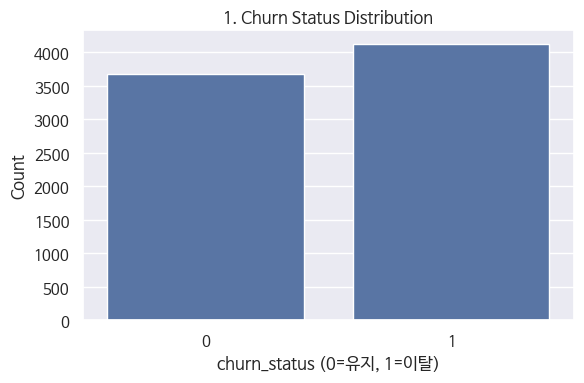

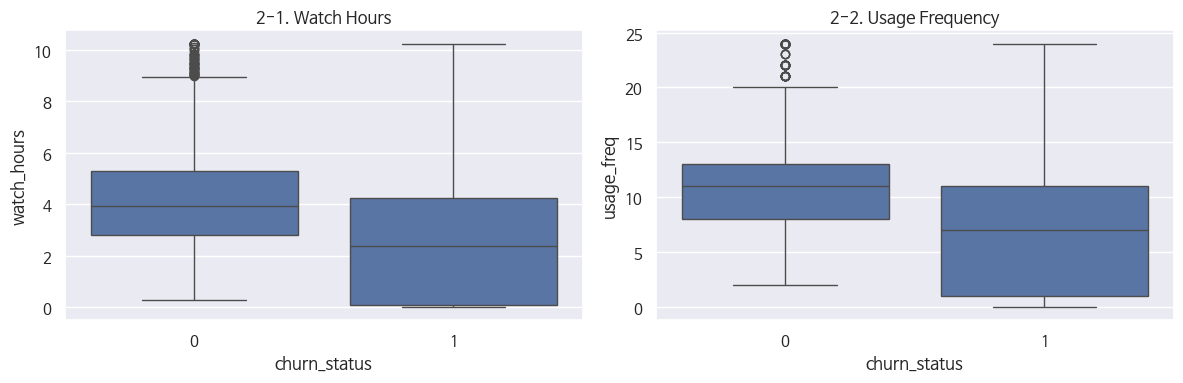

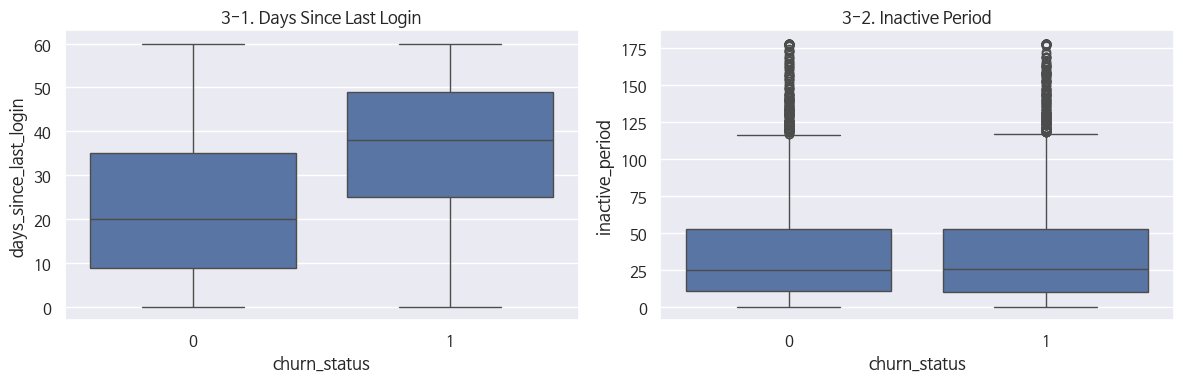

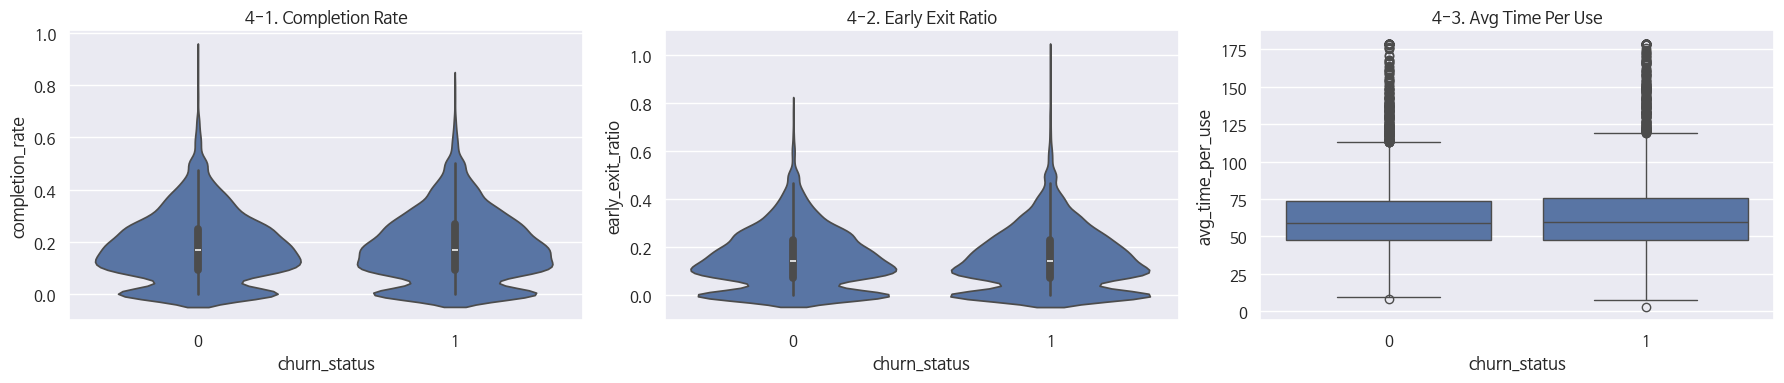

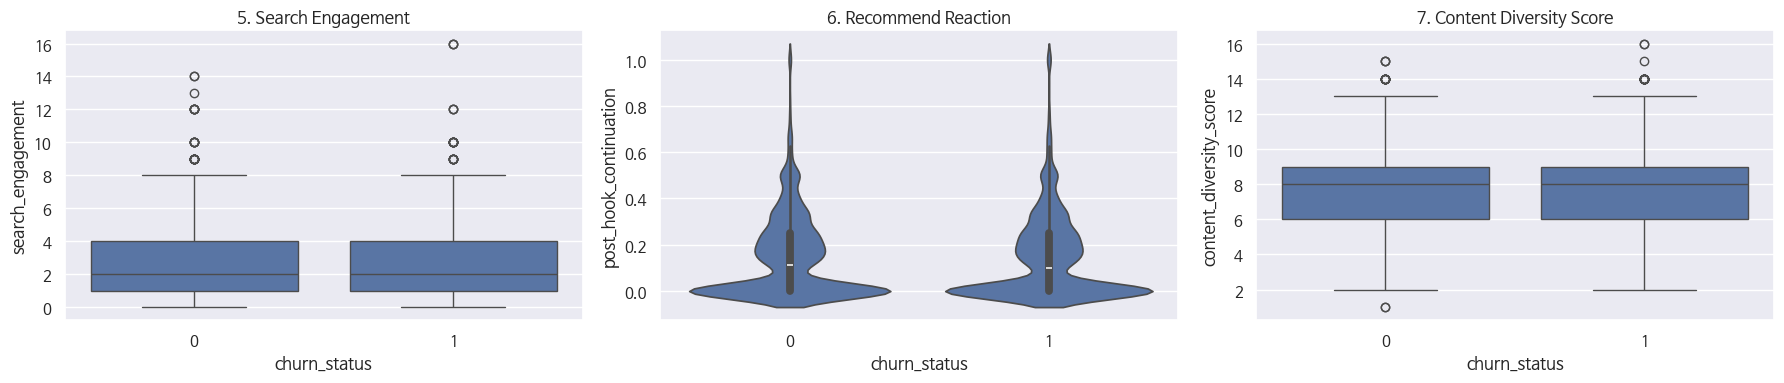

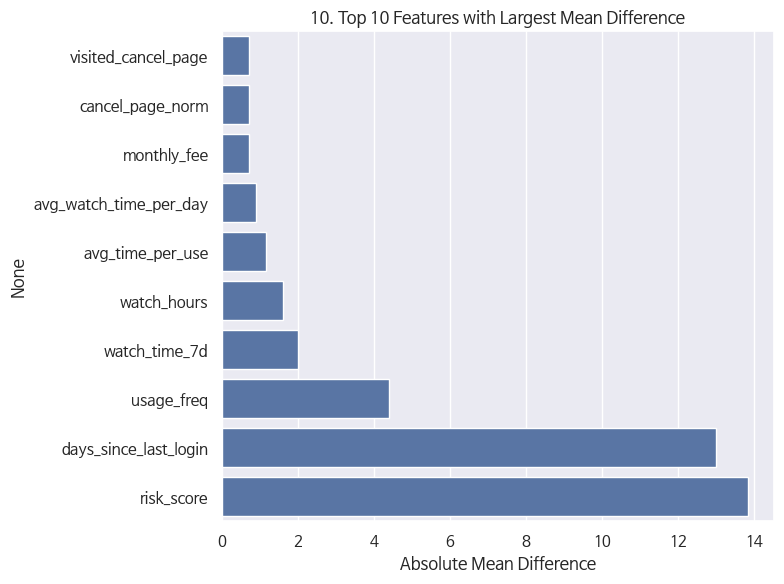


[11] 최종 파생컬럼 / risk / persona 추가 EDA


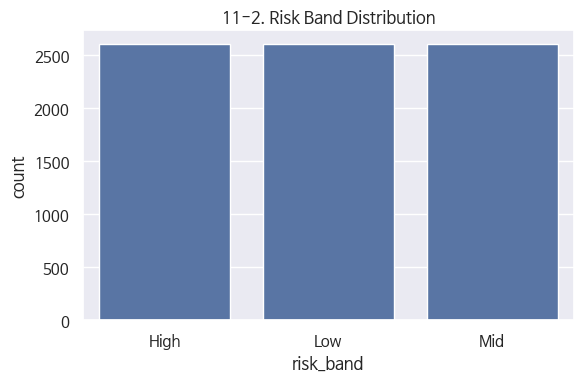

/tmp/ipykernel_31341/1262988685.py:259: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="persona_type", order=order, palette="muted")


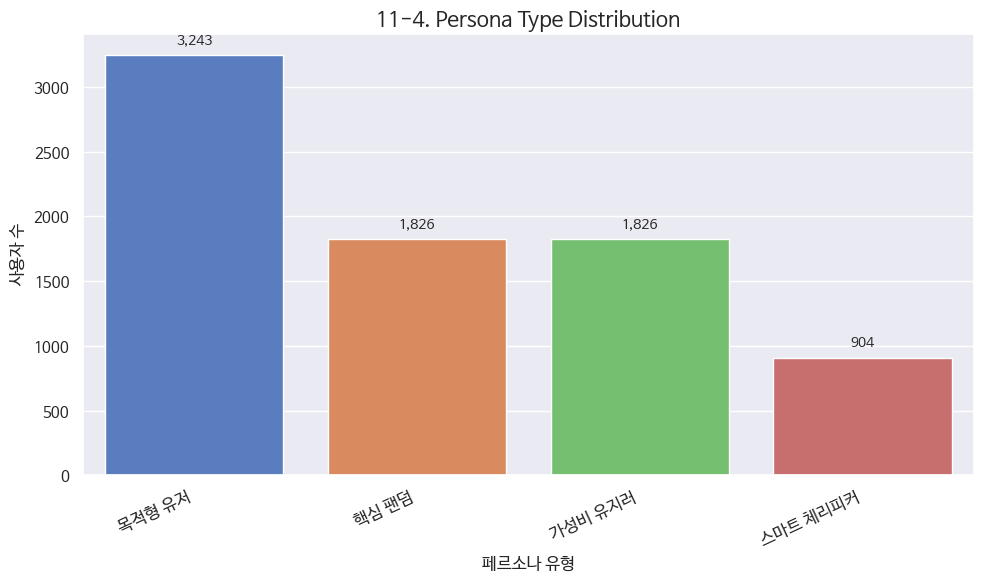


EDA 분석 및 시각화 프로세스가 모두 완료되었습니다.


In [8]:
import os
import subprocess
import platform
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import numpy as np

# =========================================================
# [필독] 한글 깨짐 방지 및 시각화 환경 설정 - 환경 자동 감지 버전
# =========================================================
def setup_korean_font():
    system_name = platform.system().lower()

    # 1) 운영체제별 기본 후보
    if "windows" in system_name:
        font_candidates = [
            r"C:\Windows\Fonts\malgun.ttf",
            r"C:\Windows\Fonts\malgunsl.ttf"
        ]
    elif "darwin" in system_name:
        font_candidates = [
            "/System/Library/Fonts/AppleGothic.ttf"
        ]
    else:
        # Linux / Colab / WSL / 원격 커널
        font_candidates = [
            "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
            "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
            "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
            "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc"
        ]

    font_path = None
    font_name = None

    # 2) 파일 경로 직접 탐색
    for path in font_candidates:
        if os.path.exists(path):
            try:
                fm.fontManager.addfont(path)
            except Exception:
                pass
            font_path = path
            font_name = fm.FontProperties(fname=path).get_name()
            break

    # 3) Linux인데 폰트가 없으면 설치 시도
    if font_name is None and "windows" not in system_name and "darwin" not in system_name:
        try:
            subprocess.run(["apt-get", "update", "-qq"], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            subprocess.run(["fc-cache", "-fv"], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            fm._load_fontmanager(try_read_cache=False)

            retry_candidates = [
                "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
                "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
            ]
            for path in retry_candidates:
                if os.path.exists(path):
                    try:
                        fm.fontManager.addfont(path)
                    except Exception:
                        pass
                    font_path = path
                    font_name = fm.FontProperties(fname=path).get_name()
                    break
        except Exception:
            pass

    # 4) 설치된 폰트 이름으로 재탐색
    if font_name is None:
        installed_fonts = {f.name for f in fm.fontManager.ttflist}
        for candidate in [
            "NanumBarunGothic", "NanumGothic",
            "Malgun Gothic", "AppleGothic",
            "Noto Sans CJK KR", "Noto Sans KR"
        ]:
            if candidate in installed_fonts:
                font_name = candidate
                break

    # 5) 최종 실패 시 기본 sans-serif로 두되 안내
    if font_name is None:
        print("경고: 사용 가능한 한글 폰트를 찾지 못했습니다. 현재 환경에 한글 폰트가 없습니다.")
        font_name = "DejaVu Sans"

    # 6) rcParams 강제 적용
    mpl.rcParams["font.family"] = font_name
    mpl.rcParams["font.sans-serif"] = [font_name]
    mpl.rcParams["axes.unicode_minus"] = False

    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.sans-serif"] = [font_name]
    plt.rcParams["axes.unicode_minus"] = False

    sns.set_theme(style="whitegrid")
    sns.set(font=font_name)

    # 7) 폰트 속성 객체
    try:
        if font_path is not None:
            font_prop = fm.FontProperties(fname=font_path)
        else:
            font_prop = fm.FontProperties(family=font_name)
    except Exception:
        font_prop = fm.FontProperties()

    print(f"실행 커널 OS: {platform.system()}")
    print(f"적용된 한글 폰트: {font_name}")
    if font_path is not None:
        print(f"폰트 경로: {font_path}")

    return font_name, font_prop


font_name, font_prop = setup_korean_font()

# =========================================================
# 0. 데이터 불러오기
# =========================================================
# 앞 단계에서 확정된 최종 mart 파일(ACTIVE_CHURN_PATH)을 읽어 EDA 대상으로 사용
df = pd.read_csv(ACTIVE_CHURN_PATH)

print("="*60)
print("OTT Churn EDA 전체 분석 (한글 폰트 & 레이아웃 수정본)")
print("="*60)

# =========================================================
# 0-1. final mart QA
# =========================================================
print("\n[0-1] final mart QA")
print("[shape]", df.shape)

if "user_id" in df.columns:
    print("[user_id 중복 수]", df["user_id"].duplicated().sum())

check_cols = [
    "search_no_click_rate_28d", "rec_ignore_rate_28d", "watch_time_delta_28d",
    "completion_to_next_start_rate", "original_core_watch_share", "had_search_28d",
    "had_rec_28d", "had_watch_delta", "had_completion_history", "had_core_watch_history",
    "price_sensitivity_proxy", "risk_score", "risk_band", "content_score",
    "price_score", "content_level", "price_level", "persona_type", "persona_risk_label"
]
avail_check_cols = [c for c in check_cols if c in df.columns]

if len(avail_check_cols) > 0:
    print("\n[결측 비율 %]")
    print((df[avail_check_cols].isna().mean() * 100).round(2).sort_values(ascending=False))

for col in ["risk_band", "persona_type", "persona_risk_label", "content_level", "price_level"]:
    if col in df.columns:
        print(f"\n[{col} 분포]")
        print(df[col].value_counts(dropna=False))

# =========================================================
# 1. Churn 분포
# =========================================================
print("\n[1] Churn(이탈) 비율 분포")
print(df["churn_status"].value_counts(normalize=True).round(4) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="churn_status")
plt.title("1. Churn Status Distribution")
plt.xlabel("churn_status (0=유지, 1=이탈)", fontproperties=font_prop)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =========================================================
# 2. 활동량 비교 (시청시간, 접속빈도)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="churn_status", y="watch_hours", ax=axes[0])
axes[0].set_title("2-1. Watch Hours")
sns.boxplot(data=df, x="churn_status", y="usage_freq", ax=axes[1])
axes[1].set_title("2-2. Usage Frequency")
plt.tight_layout()
plt.show()

# =========================================================
# 3. 최근성 비교 (마지막 접속일, 미접속 기간)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="churn_status", y="days_since_last_login", ax=axes[0])
axes[0].set_title("3-1. Days Since Last Login")
sns.boxplot(data=df, x="churn_status", y="inactive_period", ax=axes[1])
axes[1].set_title("3-2. Inactive Period")
plt.tight_layout()
plt.show()

# =========================================================
# 4. 몰입도 비교 (완주율, 초기 이탈률, 1회 시청시간)
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.violinplot(data=df, x="churn_status", y="completion_rate", ax=axes[0])
axes[0].set_title("4-1. Completion Rate")
sns.violinplot(data=df, x="churn_status", y="early_exit_ratio", ax=axes[1])
axes[1].set_title("4-2. Early Exit Ratio")
sns.boxplot(data=df, x="churn_status", y="avg_time_per_use", ax=axes[2])
axes[2].set_title("4-3. Avg Time Per Use")
plt.tight_layout()
plt.show()

# =========================================================
# 5 ~ 7. 탐색, 추천, 다양성 지표
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(data=df, x="churn_status", y="search_engagement", ax=axes[0])
axes[0].set_title("5. Search Engagement")
sns.violinplot(data=df, x="churn_status", y="post_hook_continuation", ax=axes[1])
axes[1].set_title("6. Recommend Reaction")
sns.boxplot(data=df, x="churn_status", y="content_diversity_score", ax=axes[2])
axes[2].set_title("7. Content Diversity Score")
plt.tight_layout()
plt.show()

# =========================================================
# 10. 평균 차이 기준 Top 10 변수
# =========================================================
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if "churn_status" in numeric_cols:
    numeric_cols.remove("churn_status")

mean_diff = (
    df.groupby("churn_status")[numeric_cols].mean().loc[1]
    - df.groupby("churn_status")[numeric_cols].mean().loc[0]
).abs().sort_values(ascending=False)

top10 = mean_diff.head(10).sort_values()

plt.figure(figsize=(8, 6))
sns.barplot(x=top10.values, y=top10.index, orient="h")
plt.title("10. Top 10 Features with Largest Mean Difference")
plt.xlabel("Absolute Mean Difference")
plt.tight_layout()
plt.show()

# =========================================================
# 11. 최종 파생컬럼 / risk / persona 추가 EDA
# =========================================================
print("\n[11] 최종 파생컬럼 / risk / persona 추가 EDA")

# 11-2. Risk Band 분포
if "risk_band" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x="risk_band", order=df["risk_band"].value_counts().index)
    plt.title("11-2. Risk Band Distribution")
    plt.tight_layout()
    plt.show()

# 11-4. Persona Type 분포 (한글 폰트 + 숫자 주석 정렬 버전)
if "persona_type" in df.columns:
    plt.figure(figsize=(10, 6))
    order = df["persona_type"].value_counts().index
    ax = sns.countplot(data=df, x="persona_type", order=order, palette="muted")
    plt.title("11-4. Persona Type Distribution", fontsize=15)

    plt.xlabel("페르소나 유형", fontproperties=font_prop)
    plt.ylabel("사용자 수", fontproperties=font_prop)

    for label in ax.get_xticklabels():
        label.set_fontproperties(font_prop)
        label.set_rotation(25)
        label.set_ha("right")

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{int(height):,}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("EDA 분석 및 시각화 프로세스가 모두 완료되었습니다.")
print("="*60)

## 4. 패널 생성

In [9]:
import os  # 폴더 생성용
import pandas as pd  # 데이터 처리
import numpy as np  # 수치 계산

# =========================================
# 0) 파일 경로
# =========================================
WATCH_PATH = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_watch_2025.csv"  # 시청 로그 경로
SEARCH_PATH = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_search_2025.csv"  # 검색 로그 경로
RECOMMEND_PATH = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_recommend_2025.csv"  # 추천 로그 경로
CONTENT_PATH = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/content_catalog_2025.csv"  # 콘텐츠 메타데이터 경로
USER_MASTER_PATH = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_churn_final.csv"  # 최종 유저 마트 경로
ACTIVE_CHURN_PATH = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_churn_final.csv"  # EDA 기준 파일 경로

# 저장 경로 추가 (기존 에러 방지용)
OUTPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/weekly_snapshot_panel_28d_features_14d_label.csv"  # 최종 패널 저장 경로
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)  # 저장 폴더가 없으면 자동 생성

# =========================================
# 1) 파라미터  # 관찰 윈도우/라벨 윈도우 기준
# =========================================
LOOKBACK_DAYS = 28  # snapshot 시점 직전 28일을 feature window로 사용
LABEL_HORIZON_DAYS = 14  # snapshot 시점 이후 14일을 label window로 사용
SNAPSHOT_FREQ = "7D"  # snapshot을 7일 간격으로 생성

# 이전 파일 스타일로 주간 snapshot
SNAPSHOT_START = "2025-01-29"  # 첫 snapshot 시작일
SNAPSHOT_END = "2025-12-10"  # 마지막 snapshot 종료일

# =========================================
# 2) 로드
# =========================================
watch = pd.read_csv(WATCH_PATH)  # 시청 로그 로드
search = pd.read_csv(SEARCH_PATH)  # 검색 로그 로드
recommend = pd.read_csv(RECOMMEND_PATH)  # 추천 로그 로드
content = pd.read_csv(CONTENT_PATH)  # 콘텐츠 정보 로드
user_master = pd.read_csv(USER_MASTER_PATH)  # 최종 유저 마스터 로드

# =========================================
# 3) 전처리
# =========================================
# ---------- timestamps ----------
# 시간 계산과 window slicing을 위해 timestamp를 datetime으로 변환
watch["timestamp"] = pd.to_datetime(watch["timestamp"], errors="coerce")
search["timestamp"] = pd.to_datetime(search["timestamp"], errors="coerce")
recommend["timestamp"] = pd.to_datetime(recommend["timestamp"], errors="coerce")

# user_id 또는 timestamp가 없는 행은 snapshot 집계에 사용할 수 없으므로 제거
watch = watch.dropna(subset=["user_id", "timestamp"])
search = search.dropna(subset=["user_id", "timestamp"])
recommend = recommend.dropna(subset=["user_id", "timestamp"])
user_master = user_master.dropna(subset=["user_id"]).drop_duplicates(subset=["user_id"])  # 유저 마스터는 user_id 기준 중복 제거

# 날짜 단위 window 집계를 위해 시/분/초를 제거한 event_date 생성
watch["event_date"] = watch["timestamp"].dt.normalize()
search["event_date"] = search["timestamp"].dt.normalize()
recommend["event_date"] = recommend["timestamp"].dt.normalize()

# ---------- numeric ----------
# 시청 시간과 진척률 컬럼은 계산용 numeric 타입으로 변환
watch["view_duration_minutes"] = pd.to_numeric(
    watch["view_duration_minutes"], errors="coerce"
).fillna(0)

watch["progress_percentage"] = pd.to_numeric(
    watch["progress_percentage"], errors="coerce"
).fillna(0)

# 검색 클릭 여부를 0/1 정수형으로 정리
search["is_clicked"] = (
    pd.to_numeric(search["is_clicked"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# 추천 클릭 여부도 다양한 원본 표현(True/False 문자열 포함)을 0/1로 통일
recommend["was_clicked"] = (
    recommend["was_clicked"]
    .replace({True: 1, False: 0, "True": 1, "False": 0})
    .infer_objects(copy=False)
)
recommend["was_clicked"] = (
    pd.to_numeric(recommend["was_clicked"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# ---------- time flags ----------
# 야간/주말 시청 패턴 파생변수를 만들기 위한 시간대 플래그
watch["hour"] = watch["timestamp"].dt.hour
watch["dayofweek"] = watch["timestamp"].dt.dayofweek
watch["is_night"] = watch["hour"].between(21, 23).astype(int)  # 21~23시는 야간 시청으로 간주
watch["is_weekend"] = watch["dayofweek"].isin([5, 6]).astype(int)  # 토/일은 주말 시청으로 간주

# ---------- content merge (for genre / original 비중) ----------
# 콘텐츠 테이블에서 실제 사용할 컬럼만 남기고 중복 제거
content = content[["movie_id", "genre_primary", "content_type"]].drop_duplicates()

# watch 로그에 콘텐츠 메타정보를 붙여 장르/오리지널 비중 관련 파생변수 계산에 활용
watch = watch.merge(
    content.rename(columns={
        "genre_primary": "catalog_genre_primary",
        "content_type": "catalog_content_type"
    }),
    on="movie_id",
    how="left"
)

# ---------- merge coverage QA ----------
# content_type 결합률 확인: movie_id 기준 merge가 얼마나 잘 붙었는지 QA 출력
if "catalog_content_type" in watch.columns:
    match_rate = 1 - watch["catalog_content_type"].isna().mean()
    print(f"[QA] watch-content merge match rate: {match_rate:.4f}")

# genre 정보 결합률 확인
if "catalog_genre_primary" in watch.columns:
    genre_coverage = 1 - watch["catalog_genre_primary"].isna().mean()
    print(f"[QA] watch-content genre coverage: {genre_coverage:.4f}")

# watch 로그 안의 genre_primary가 있으면 우선 사용, 없으면 catalog 값으로 보완
if "genre_primary" in watch.columns:
    watch["genre_for_count"] = watch["genre_primary"]  # 로그 원본 장르값 우선 사용
else:
    watch["genre_for_count"] = np.nan  # 해당 컬럼이 없으면 빈 값으로 시작

watch.loc[watch["genre_for_count"].isna(), "genre_for_count"] = watch["catalog_genre_primary"]  # 결측인 경우 catalog 장르로 채움

# original/core 유사 플래그
# content_type == "only" 인 경우를 original/core 시청으로 간주
watch["is_original_core"] = (watch["catalog_content_type"] == "only").astype(int)

# =========================================
# 4) 정적 / 프로필 컬럼
# =========================================
# synthetic_churn_final에서 snapshot별 동적 변수와 함께 붙일 user-level static 정보 목록
static_cols = [
    "user_id", "age", "gender", "subscription_plan", "watch_hours", "days_since_last_login",
    "device", "monthly_fee", "payment_method", "number_of_profiles", "avg_watch_time_per_day",
    "favorite_genre", "signup_date", "avg_weekly_usage_hours", "support_tickets", "payment_failures",
    "tenure_months", "viewing_time_decline_rate", "watch_time_7d", "completion_rate", "avg_time_per_use",
    "early_exit_ratio", "high_engagement_index", "inactive_period", "usage_freq", "activity_density_7d",
    "search_engagement", "freq_smartphone", "freq_tv_set", "genre_concentration_index",
    "content_diversity_score", "post_hook_continuation", "first_watch_content_48h", "support_tickets_is_missing",
    "payment_failures_is_missing", "acct_first_playback_date", "acct_last_playback_date", "first_event_ts",
    "search_no_click_rate_28d", "rec_ignore_rate_28d", "watch_time_delta_28d", "completion_to_next_start_rate",
    "original_core_watch_share", "had_search_28d", "had_rec_28d", "had_watch_delta", "had_completion_history",
    "had_core_watch_history", "plan_price_sensitivity_score", "monthly_fee_norm", "payment_failures_norm",
    "content_score", "price_score", "content_level", "price_level", "persona_type"
]

# 실제 user_master에 존재하는 컬럼만 남겨서 오류 방지
static_cols = [c for c in static_cols if c in user_master.columns]
user_static = user_master[static_cols].drop_duplicates(subset=["user_id"]).copy()  # user_id 기준 1행씩 유지

# =========================================
# 5) snapshot 골격
# =========================================
# 주어진 기간에 대해 7일 간격 snapshot 날짜 생성
snapshots = pd.date_range(
    start=SNAPSHOT_START,
    end=SNAPSHOT_END,
    freq=SNAPSHOT_FREQ
)

all_users = user_static["user_id"].dropna().unique()  # snapshot panel에 포함할 전체 유저 목록

# 전체 유저 x 전체 snapshot 날짜의 Cartesian product로 panel 골격 생성
base_panel = pd.MultiIndex.from_product(
    [all_users, snapshots],
    names=["user_id", "snapshot_date"]
).to_frame(index=False)

# =========================================
# 6) snapshot별 집계
# =========================================
result_frames = []  # 각 snapshot별 결과를 누적해서 마지막에 concat

for snap_date in snapshots:
    # 현재 snapshot 기준 직전 28일 구간
    current_start = snap_date - pd.Timedelta(days=LOOKBACK_DAYS)
    current_end = snap_date

    # 직전 비교용 이전 28일 구간
    prev_start = snap_date - pd.Timedelta(days=LOOKBACK_DAYS * 2)
    prev_end = snap_date - pd.Timedelta(days=LOOKBACK_DAYS)

    # 라벨용 미래 14일 종료일
    future_end = snap_date + pd.Timedelta(days=LABEL_HORIZON_DAYS)

    # -------------------------------------
    # A. watch current 28d
    # -------------------------------------
    # 현재 snapshot 직전 28일 동안의 시청 로그만 필터링
    watch_cur = watch[
        (watch["event_date"] >= current_start) &
        (watch["event_date"] < current_end)
    ].copy()

    if len(watch_cur) > 0:
        # 진척률 90% 이상이면 completion으로 간주
        watch_cur["completed_flag"] = (watch_cur["progress_percentage"] >= 90).astype(int)

        # Device 분리
        # Tablet/PC 사용 빈도 파생변수 생성을 위한 기기 플래그
        if "device_type" in watch_cur.columns:
            watch_cur["is_tablet"] = (watch_cur["device_type"] == "Tablet").astype(int)
            watch_cur["is_pc"] = watch_cur["device_type"].isin(["Desktop", "Laptop"]).astype(int)
        else:
            watch_cur["is_tablet"] = 0
            watch_cur["is_pc"] = 0

        # 다음 시청까지의 간격을 계산하려면 유저-시간 기준 정렬 필요
        watch_cur = watch_cur.sort_values(["user_id", "timestamp"])
        watch_cur["next_watch_gap_hours"] = (
            watch_cur.groupby("user_id")["timestamp"].shift(-1) - watch_cur["timestamp"]
        ).dt.total_seconds() / 3600

        # 완료 후 24시간 이내 다음 시청이 이어졌는지 확인
        watch_cur["next_start_within_24h"] = (
            (watch_cur["next_watch_gap_hours"] >= 0) &
            (watch_cur["next_watch_gap_hours"] <= 24)
        ).fillna(False).astype(int)

        # session_id가 있으면 세션 단위 count, 없으면 fallback으로 event_date 기준 size 사용
        watch_count_base = "session_id" if "session_id" in watch_cur.columns else "event_date"

        # 현재 28일 구간의 핵심 시청 feature 집계
        watch_feat_cur = (
            watch_cur.groupby("user_id")
            .agg(
                total_watch_time=("view_duration_minutes", "sum"),  # 총 시청 시간
                total_watch_count=(watch_count_base, "size"),  # 총 시청 횟수
                active_days=("event_date", "nunique"),  # 시청한 날짜 수
                avg_progress=("progress_percentage", "mean"),  # 평균 진척률
                unique_content_count=("movie_id", "nunique"),  # 시청한 고유 콘텐츠 수
                unique_genre_count=("genre_for_count", "nunique"),  # 시청한 고유 장르 수
                night_watch_count=("is_night", "sum"),  # 야간 시청 횟수
                weekend_watch_count=("is_weekend", "sum"),  # 주말 시청 횟수
                watch_time_28d=("view_duration_minutes", "sum"),  # 최근 28일 총 시청 시간
                last_watch_date=("event_date", "max"),  # 마지막 시청일
                completion_count=("completed_flag", "sum"),  # 완료 시청 횟수
                completion_to_next_start_rate_num=("next_start_within_24h", "sum"),  # 완료 후 24시간 내 다음 시청 횟수
                original_core_watch_minutes=(
                    "view_duration_minutes",
                    lambda x: x[watch_cur.loc[x.index, "is_original_core"] == 1].sum()
                ),  # original/core 콘텐츠 시청 시간
                freq_tablet=("is_tablet", "sum"),  # Tablet 이용 횟수
                freq_pc=("is_pc", "sum")  # PC 이용 횟수
            )
            .reset_index()
        )
    else:
        # 해당 snapshot 구간에 watch 로그가 전혀 없을 경우 빈 집계 프레임 생성
        watch_feat_cur = pd.DataFrame(columns=[
            "user_id", "total_watch_time", "total_watch_count", "active_days",
            "avg_progress", "unique_content_count", "unique_genre_count",
            "night_watch_count", "weekend_watch_count", "watch_time_28d",
            "last_watch_date", "completion_count", "completion_to_next_start_rate_num",
            "original_core_watch_minutes", "freq_tablet", "freq_pc"
        ])

    # -------------------------------------
    # B. watch prev 28d
    # -------------------------------------
    # 직전 비교용 이전 28일 시청 로그
    watch_prev = watch[
        (watch["event_date"] >= prev_start) &
        (watch["event_date"] < prev_end)
    ].copy()

    # 최근 28일과 비교하기 위한 이전 28일 총 시청시간 집계
    watch_feat_prev = (
        watch_prev.groupby("user_id")
        .agg(
            watch_time_prev_28d=("view_duration_minutes", "sum")
        )
        .reset_index()
    )

    # -------------------------------------
    # C. future 14d label source
    # -------------------------------------
    # snapshot 이후 14일 동안 실제 시청이 있었는지 확인하는 라벨 소스
    watch_future = watch[
        (watch["event_date"] > snap_date) &
        (watch["event_date"] <= future_end)
    ].copy()

    # 미래 14일 동안의 시청 횟수 집계
    watch_future_label = (
        watch_future.groupby("user_id")
        .size()
        .rename("watch_counts_next_14d")
        .reset_index()
    )

    # -------------------------------------
    # D. search current 28d
    # -------------------------------------
    # 최근 28일 검색 로그 필터링
    search_cur = search[
        (search["event_date"] >= current_start) &
        (search["event_date"] < current_end)
    ].copy()

    # search_id가 있으면 검색 이벤트 기준, 없으면 fallback 사용
    search_count_base = "search_id" if "search_id" in search_cur.columns else "event_date"

    # 검색 횟수/클릭 수/마지막 검색일 집계
    search_feat = (
        search_cur.groupby("user_id")
        .agg(
            total_search_count=(search_count_base, "nunique"),
            search_click_sum=("is_clicked", "sum"),
            last_search_date=("event_date", "max")
        )
        .reset_index()
    )

    # -------------------------------------
    # E. recommend current 28d
    # -------------------------------------
    # 최근 28일 추천 노출 로그 필터링
    rec_cur = recommend[
        (recommend["event_date"] >= current_start) &
        (recommend["event_date"] < current_end)
    ].copy()

    # recommendation_id가 있으면 노출 이벤트 기준, 없으면 fallback 사용
    rec_count_base = "recommendation_id" if "recommendation_id" in rec_cur.columns else "event_date"

    # 추천 노출 수 / 추천 클릭 수 집계
    rec_feat = (
        rec_cur.groupby("user_id")
        .agg(
            total_recommend_exposure=(rec_count_base, "nunique"),
            recommend_click_sum=("was_clicked", "sum")
        )
        .reset_index()
    )

    # -------------------------------------
    # F. snapshot panel merge
    # -------------------------------------
    # 현재 snapshot 날짜에 해당하는 골격 panel만 추출
    panel_cur = base_panel[base_panel["snapshot_date"] == snap_date].copy()

    # 현재 28일 feature + 이전 28일 feature + 미래 14일 label source + 정적 정보 결합
    panel_cur = (
        panel_cur
        .merge(watch_feat_cur, on="user_id", how="left")
        .merge(watch_feat_prev, on="user_id", how="left")
        .merge(search_feat, on="user_id", how="left")
        .merge(rec_feat, on="user_id", how="left")
        .merge(watch_future_label, on="user_id", how="left")
        .merge(user_static, on="user_id", how="left")
    )

    # -------------------------------------
    # G. fillna
    # -------------------------------------
    # 활동이 없어서 생긴 결측치는 0으로 채워 panel 계산 안정화
    zero_fill_cols = [
        "total_watch_time", "total_watch_count", "active_days", "avg_progress",
        "unique_content_count", "unique_genre_count", "night_watch_count", "weekend_watch_count",
        "watch_time_28d", "completion_count", "completion_to_next_start_rate_num",
        "original_core_watch_minutes", "watch_time_prev_28d", "watch_counts_next_14d",
        "total_search_count", "search_click_sum", "total_recommend_exposure", "recommend_click_sum",
        "freq_tablet", "freq_pc"
    ]
    zero_fill_cols = [c for c in zero_fill_cols if c in panel_cur.columns]
    panel_cur[zero_fill_cols] = panel_cur[zero_fill_cols].fillna(0)

    # -------------------------------------
    # H. derived vars
    # -------------------------------------
    # 마지막 시청일 기준 최근성 변수
    panel_cur["days_since_last_watch"] = (snap_date.normalize() - pd.to_datetime(panel_cur["last_watch_date"])).dt.days
    panel_cur["days_since_last_watch"] = panel_cur["days_since_last_watch"].fillna(9999)  # 시청 이력이 없으면 큰 값으로 처리

    # 마지막 검색일 기준 최근성 변수
    panel_cur["days_since_last_search"] = (snap_date.normalize() - pd.to_datetime(panel_cur["last_search_date"])).dt.days
    panel_cur["days_since_last_search"] = panel_cur["days_since_last_search"].fillna(9999)  # 검색 이력이 없으면 큰 값으로 처리

    # 전체 시청 중 야간 시청 비중
    panel_cur["night_watch_ratio"] = np.where(
        panel_cur["total_watch_count"] > 0,
        panel_cur["night_watch_count"] / panel_cur["total_watch_count"],
        0
    )

    # 전체 시청 중 주말 시청 비중
    panel_cur["weekend_watch_ratio"] = np.where(
        panel_cur["total_watch_count"] > 0,
        panel_cur["weekend_watch_count"] / panel_cur["total_watch_count"],
        0
    )

    # 이전 28일 대비 최근 28일 시청 감소율
    panel_cur["watch_decline_rate"] = np.where(
        panel_cur["watch_time_prev_28d"] > 0,
        (panel_cur["watch_time_prev_28d"] - panel_cur["watch_time_28d"]) / panel_cur["watch_time_prev_28d"],
        0
    )

    # 검색 클릭률
    panel_cur["search_click_rate"] = np.where(
        panel_cur["total_search_count"] > 0,
        panel_cur["search_click_sum"] / panel_cur["total_search_count"],
        0
    )

    # 추천 클릭률
    panel_cur["recommend_click_rate"] = np.where(
        panel_cur["total_recommend_exposure"] > 0,
        panel_cur["recommend_click_sum"] / panel_cur["total_recommend_exposure"],
        0
    )

    # 시청량 기준 세그먼트
    # 각 snapshot 내부 분포 기준으로 상위 30% / 하위 30% / 중간 구간 분리
    q30 = panel_cur["watch_time_28d"].quantile(0.3)
    q70 = panel_cur["watch_time_28d"].quantile(0.7)
    panel_cur["segment_volume"] = np.where(
        panel_cur["watch_time_28d"] >= q70, "Heavy_Viewer",
        np.where(panel_cur["watch_time_28d"] <= q30, "Light_Viewer", "Medium")
    )

    # 탐색 성향 세그먼트
    # 검색량이 snapshot 중앙값보다 높고 검색 클릭률이 추천 클릭률보다 높으면 Search_Active
    med_search = panel_cur["total_search_count"].median()
    panel_cur["segment_explore"] = np.where(
        (panel_cur["total_search_count"] > med_search) &
        (panel_cur["search_click_rate"] > panel_cur["recommend_click_rate"]),
        "Search_Active",
        "Recommend_Passive"
    )

    # 장르 취향 세그먼트
    # 최근 28일 동안 4개 이상 장르를 소비하면 Diverse_Taste로 분류
    panel_cur["segment_taste"] = np.where(
        panel_cur["unique_genre_count"] >= 4,
        "Diverse_Taste",
        "Niche_Taste"
    )

    # 기존 최종 mart 파생변수와 유사한 rebuilt 변수들
    panel_cur["search_no_click_rate_28d_rebuilt"] = np.where(
        panel_cur["total_search_count"] > 0,
        1 - panel_cur["search_click_rate"],
        0
    )

    panel_cur["rec_ignore_rate_28d_rebuilt"] = np.where(
        panel_cur["total_recommend_exposure"] > 0,
        1 - panel_cur["recommend_click_rate"],
        0
    )

    panel_cur["watch_time_delta_28d_rebuilt"] = (
        panel_cur["watch_time_28d"] - panel_cur["watch_time_prev_28d"]
    )

    panel_cur["completion_to_next_start_rate_rebuilt"] = np.where(
        panel_cur["completion_count"] > 0,
        panel_cur["completion_to_next_start_rate_num"] / panel_cur["completion_count"],
        0
    )

    panel_cur["original_core_watch_share_rebuilt"] = np.where(
        panel_cur["watch_time_28d"] > 0,
        panel_cur["original_core_watch_minutes"] / panel_cur["watch_time_28d"],
        0
    )

    # 활동 여부 플래그 변수
    panel_cur["had_search_28d_rebuilt"] = (panel_cur["total_search_count"] > 0).astype(int)
    panel_cur["had_rec_28d_rebuilt"] = (panel_cur["total_recommend_exposure"] > 0).astype(int)
    panel_cur["had_watch_delta_rebuilt"] = (panel_cur["watch_time_prev_28d"] > 0).astype(int)
    panel_cur["had_completion_history_rebuilt"] = (panel_cur["completion_count"] > 0).astype(int)
    panel_cur["had_core_watch_history_rebuilt"] = (panel_cur["original_core_watch_minutes"] > 0).astype(int)

    # 최종 churn label
    # 미래 14일 동안 시청 횟수가 0이면 churn으로 간주
    panel_cur["churn_label"] = (panel_cur["watch_counts_next_14d"] == 0).astype(int)

    result_frames.append(panel_cur)  # 현재 snapshot 결과를 누적 리스트에 저장

# =========================================
# 7) 최종 결합
# =========================================
panel = pd.concat(result_frames, ignore_index=True)  # snapshot별 결과를 하나의 panel로 결합

# =========================================
# 8) 타입 정리
# =========================================
# count/flag 성격의 변수들은 int로 맞춰 후속 모델링 및 저장 안정성 확보
int_cols = [
    "total_watch_count", "active_days", "unique_content_count", "unique_genre_count",
    "night_watch_count", "weekend_watch_count", "watch_counts_next_14d", "total_search_count",
    "total_recommend_exposure", "had_search_28d_rebuilt", "had_rec_28d_rebuilt",
    "had_watch_delta_rebuilt", "had_completion_history_rebuilt", "had_core_watch_history_rebuilt",
    "churn_label", "freq_tablet", "freq_pc"
]
for col in int_cols:
    if col in panel.columns:
        panel[col] = panel[col].fillna(0).astype(int)

# =========================================
# 9) 컬럼 순서
# =========================================
# 모델링과 확인이 편하도록 핵심 snapshot 변수들을 앞쪽으로 정렬
front_cols = [
    "user_id",
    "snapshot_date",
    "churn_label",
    "watch_counts_next_14d",
    "segment_volume",
    "segment_explore",
    "segment_taste",
    "freq_smartphone",
    "freq_tv_set",
    "freq_tablet",
    "freq_pc",
    "total_watch_time",
    "total_watch_count",
    "active_days",
    "avg_progress",
    "unique_content_count",
    "unique_genre_count",
    "night_watch_count",
    "weekend_watch_count",
    "watch_time_28d",
    "watch_time_prev_28d",
    "days_since_last_watch",
    "night_watch_ratio",
    "weekend_watch_ratio",
    "watch_decline_rate",
    "total_search_count",
    "search_click_rate",
    "days_since_last_search",
    "total_recommend_exposure",
    "recommend_click_rate",
    "search_no_click_rate_28d_rebuilt",
    "rec_ignore_rate_28d_rebuilt",
    "watch_time_delta_28d_rebuilt",
    "completion_to_next_start_rate_rebuilt",
    "original_core_watch_share_rebuilt",
    "had_search_28d_rebuilt",
    "had_rec_28d_rebuilt",
    "had_watch_delta_rebuilt",
    "had_completion_history_rebuilt",
    "had_core_watch_history_rebuilt",
]

# user_static의 나머지 정적 컬럼은 뒤쪽에 이어 붙임
static_rest = [c for c in user_static.columns if c != "user_id"]
final_cols = front_cols + [c for c in static_rest if c not in front_cols]

# 실제 존재하는 컬럼만 선택해서 최종 panel 구성
panel = panel[[c for c in final_cols if c in panel.columns]]

# =========================================
# 10) 저장
# =========================================
panel = panel.sort_values(["user_id", "snapshot_date"]).reset_index(drop=True)  # user_id, snapshot_date 기준 정렬
panel.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")  # 최종 snapshot panel 저장

# =========================================
# 11) 체크 출력
# =========================================
print("saved:", OUTPUT_PATH)  # 저장 경로 확인
print("shape:", panel.shape)  # 전체 행/열 수 확인
print("users:", panel["user_id"].nunique())  # 유저 수 확인
print("snapshots:", panel["snapshot_date"].nunique())  # snapshot 개수 확인
print("snapshot range:", panel["snapshot_date"].min(), "~", panel["snapshot_date"].max())  # snapshot 범위 확인
print("churn rate:", round(panel["churn_label"].mean(), 4))  # 전체 churn 비율 확인
print("\n[추가된 세그먼트 및 디바이스 데이터 미리보기]")

preview_cols = [
    "user_id",
    "snapshot_date",
    "segment_volume",
    "segment_explore",
    "segment_taste",
    "freq_tablet",
    "freq_pc"
]
preview_cols = [c for c in preview_cols if c in panel.columns]  # 실제 존재하는 미리보기 컬럼만 선택
print(panel[preview_cols].head())  # 세그먼트/디바이스 컬럼 샘플 출력

/tmp/ipykernel_31341/1545806169.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({True: 1, False: 0, "True": 1, "False": 0})


[QA] watch-content merge match rate: 1.0000
[QA] watch-content genre coverage: 1.0000
saved: /content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/weekly_snapshot_panel_28d_features_14d_label.csv
shape: (358754, 93)
users: 7799
snapshots: 46
snapshot range: 2025-01-29 00:00:00 ~ 2025-12-10 00:00:00
churn rate: 0.7476

[추가된 세그먼트 및 디바이스 데이터 미리보기]
      user_id snapshot_date segment_volume    segment_explore segment_taste  \
0  user_00001    2025-01-29         Medium  Recommend_Passive   Niche_Taste   
1  user_00001    2025-02-05         Medium  Recommend_Passive   Niche_Taste   
2  user_00001    2025-02-12   Light_Viewer  Recommend_Passive   Niche_Taste   
3  user_00001    2025-02-19   Light_Viewer  Recommend_Passive   Niche_Taste   
4  user_00001    2025-02-26   Light_Viewer  Recommend_Passive   Niche_Taste   

   freq_tablet  freq_pc  
0            0        0  
1            0        0  
2            0        0  
3            0        0  
4            0        0  


### 💡 데이터 누수(Data Leakage) 방지 및 변수 통제 로직

본 프로젝트에서는 예측 모델의 신뢰성을 확보하고 실제 서비스 적용 시 발생할 수 있는 성능 왜곡을 방지하기 위해 다음과 같은 **변수 통제 원칙**을 준수하였습니다.

#### 1. 동적 변수(Dynamic Features)의 엄격한 시간 격리
* **시청 및 활동 지표:** `watch_time_28d`, `days_since_last_watch`, `segment_volume` 등 사용자의 활동성에 기반한 모든 변수는 각 스냅샷 날짜(T)를 기준으로 **과거 28일간의 로그 데이터만**을 집계하여 생성되었습니다.
* **라벨링(Target):** 이탈 여부 판단은 스냅샷 이후 **미래 14일간의 데이터**만을 활용하여, 학습 시점에 미래의 정보를 참조하는 누수를 원천 차단했습니다.

#### 2. 정적 변수(Static Features)의 프로필화 및 통제
* `content_diversity_score`, `price_score`, `persona_type` 등 `user_master`에서 유입된 일부 변수들은 분석의 편의상 **'가입 초기 또는 특정 베이스라인 시점에 확정된 고정 프로필'**로 정의하였습니다.
* 이는 유동적인 취향 변화보다는 사용자의 **원천적인 성향(Inherent Trait)**이 이탈에 미치는 영향을 고정하여 관찰하기 위함입니다.
* 만약 해당 지표들이 시간에 따라 변하는 성격이더라도, 본 모델에서는 이를 '특정 시점의 스냅샷 정보'로 간주함으로써 실제 운영 환경에서 모델이 가질 수 있는 정보의 범위를 넘지 않도록 설계하였습니다.

#### 3. 시계열 교차 검증 (Time-Split Validation)
* 단순 랜덤 분할이 아닌, 시간 순서에 따른 **Train(과거) / Valid(현재) / Test(최신)** 분할 방식을 적용하였습니다.
* 특히 최신 스냅샷을 Test set으로 분리하여, 과거 데이터를 학습한 모델이 '미래 시점'의 유저 행동을 얼마나 정확하게 예측하는지 실무 환경과 동일하게 검증하였습니다.

## 5. 모델링

In [10]:
from pathlib import Path  # 경로 객체 처리

# 패널 생성 셀에서 이미 만든 OUTPUT_PATH를 모델링 셀의 PANEL_PATH로 연결
if "OUTPUT_PATH" not in globals():
    raise NameError("OUTPUT_PATH가 없습니다. 패널 생성 셀을 먼저 실행하세요.")

PANEL_PATH = Path(OUTPUT_PATH)  # 패널 생성 결과를 모델 입력 경로로 연결

# 원래 대시보드 셀에서 기대하는 변수 연결
WATCH_PATH_DEFAULT = Path(WATCH_PATH)  # 후속 셀에서 사용할 watch 경로

# 원래 SHAP/저장 셀에서 기대하는 출력 폴더/파일 변수 연결
OUTPUT_DIR = PANEL_PATH.parent  # 산출물 저장 폴더
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PATH = OUTPUT_DIR / "final10_lightgbm_metrics.csv"  # 모델 성능 저장 파일
DASHBOARD_FULL_PATH = OUTPUT_DIR / "dashboard_results_final10_TypeA.csv"
DASHBOARD_OPS_PATH = OUTPUT_DIR / "dashboard_results_final10_TypeA_ops.csv"

SHAP_GLOBAL_CSV = OUTPUT_DIR / "shap_global_importance.csv"
SHAP_HIGH_RISK_CSV = OUTPUT_DIR / "shap_high_risk_top_reasons.csv"
SHAP_HIGH_RISK_TEXT_CSV = OUTPUT_DIR / "shap_high_risk_top_reasons_with_text.csv"
SHAP_BEESWARM_PNG = OUTPUT_DIR / "shap_beeswarm_global.png"
SHAP_BAR_PNG = OUTPUT_DIR / "shap_bar_global.png"

print("PANEL_PATH =", PANEL_PATH)
print("WATCH_PATH_DEFAULT =", WATCH_PATH_DEFAULT)
print("OUTPUT_DIR =", OUTPUT_DIR)

PANEL_PATH = /content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/weekly_snapshot_panel_28d_features_14d_label.csv
WATCH_PATH_DEFAULT = /content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/data/synthetic_watch_2025.csv
OUTPUT_DIR = /content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs


In [11]:
!pip install autogluon -q  # AutoGluon 설치

1. 데이터 로드 중...
전처리 완료!
최종 사용 변수:
['had_core_watch_history_rebuilt', 'watch_hours', 'content_diversity_score', 'price_score', 'had_watch_delta_rebuilt', 'days_since_last_watch', 'freq_smartphone', 'freq_tv_set', 'completion_rate', 'search_engagement']


No path specified. Models will be saved in: "AutogluonModels/ag-20260409_070702"
Verbosity: 2 (Standard Logging)


Train: (343156, 11)
Valid: (7799, 11) / 기준일: 2025-12-03
Test : (7799, 11) / 기준일: 2025-12-10

========== [최종 10개 변수 LightGBM 학습 시작] ==========


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       9.74 GB / 12.67 GB (76.8%)
Disk Space Avail:   74.69 GB / 107.72 GB (69.3%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "/content/AutogluonModels/ag-20260409_070702"
Train Data Rows:    343156
Train Data Columns: 10
Tuning Data Rows:    7799
Tuning Data Columns: 10
Label Column:       target
AutoGluon infers your prediction problem is: 'binary' (because only two unique


학습된 모델:
['LightGBM_BAG_L1', 'WeightedEnsemble_L2', 'LightGBM_BAG_L2', 'WeightedEnsemble_L3']

========== [최종 모델 성능 평가 및 비교] ==========

[모델별 지표 비교 표]
              Model   PR-AUC  Precision@10  Lift@10
WeightedEnsemble_L3 0.876350           1.0 1.372339
    LightGBM_BAG_L2 0.876350           1.0 1.372339
WeightedEnsemble_L2 0.875537           1.0 1.372339
    LightGBM_BAG_L1 0.875537           1.0 1.372339


/tmp/ipykernel_31341/2873294526.py:187: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PR-AUC', y='Model', data=comparison_df, palette='viridis')


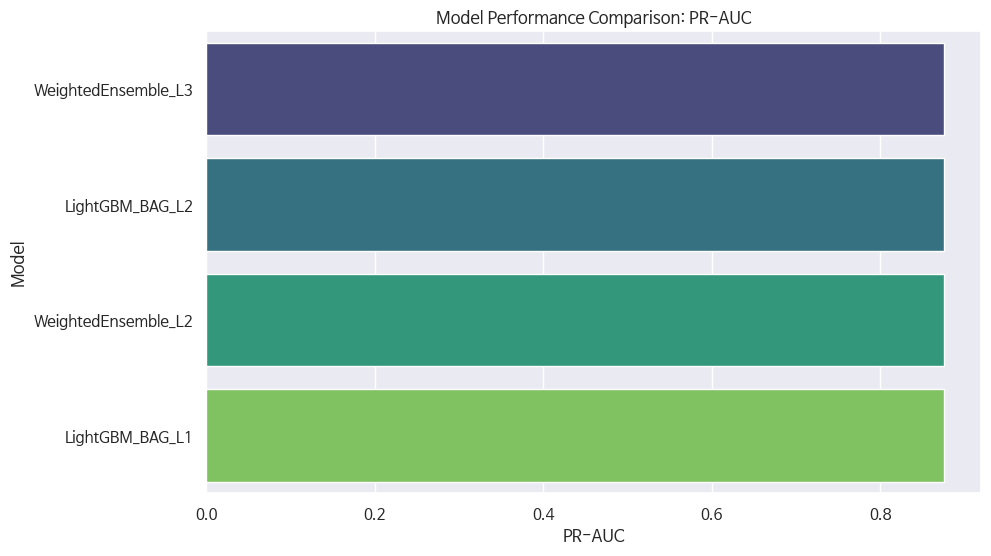


[최종 선정 모델 결과]
PR-AUC       : 0.876350

========== [Type A Risk Band 생성] ==========

저장 완료!
1) final10_lightgbm_metrics.csv             -> 최종 모델 성능
2) dashboard_results_final10_TypeA.csv      -> 검증 포함 대시보드 결과
3) dashboard_results_final10_TypeA_ops.csv  -> 운영용 대시보드 결과(target 제외)

Risk_Band 분포 (사람 수 기준 정확한 비율 확인):
Risk_Band
Low     0.5201
High    0.3500
Mid     0.1299
Name: proportion, dtype: float64


In [12]:
import pandas as pd  # 데이터 처리
import numpy as np  # 수치 계산
import shutil  # 기존 모델 폴더 삭제용
import matplotlib.pyplot as plt
import seaborn as sns
from autogluon.tabular import TabularPredictor  # AutoGluon tabular 모델 학습기
from sklearn.metrics import average_precision_score  # PR-AUC 계산용

# =========================================================
# 1. 데이터 로드
# =========================================================
print("1. 데이터 로드 중...")

file_path = str(PANEL_PATH)  # 패널 파일 경로를 문자열로 변환
df = pd.read_csv(file_path)  # snapshot panel 데이터 로드
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])  # snapshot_date를 날짜형으로 변환

# =========================================================
# 2. 전처리
# =========================================================
def preprocess_data(data):
    data = data.copy()  # 원본 훼손 방지를 위해 복사본 사용

    # churn_label을 모델 학습용 target 컬럼으로 변환
    data["target"] = data["churn_label"].astype(int)

    # favorite_genre의 Unknown/결측값을 하나의 대표값으로 정리
    if "favorite_genre" in data.columns:
        data["favorite_genre"] = data["favorite_genre"].replace({"Unknown": "Variety"}).fillna("Variety")

    # 범주형 컬럼은 문자열형으로 통일
    for col in ["gender", "subscription_plan", "favorite_genre"]:
        if col in data.columns:
            data[col] = data[col].astype(str).fillna("Unknown")

    return data

df = preprocess_data(df)  # 전처리 함수 적용
print("전처리 완료!")

# =========================================================
# 3. 최종 변수 10개 정의
# =========================================================
final_features = [  # 최종 LightGBM 모델에 사용할 핵심 피처 10개
    "had_core_watch_history_rebuilt",
    "watch_hours",
    "content_diversity_score",
    "price_score",
    "had_watch_delta_rebuilt",
    "days_since_last_watch",
    "freq_smartphone",
    "freq_tv_set",
    "completion_rate",
    "search_engagement"
]

# 실제 데이터에 존재하는 컬럼만 남겨서 에러 방지
final_features = [col for col in final_features if col in df.columns]

# 최종 피처가 하나도 없으면 학습 불가이므로 에러 발생
if len(final_features) == 0:
    raise ValueError("모델링에 사용할 final_features가 없습니다. 패널 컬럼을 확인하세요.")

extra_keep_cols = [
    "segment_volume",
    "segment_explore",
    "segment_taste",
    "freq_tablet",
    "freq_pc"
]
# 대시보드/후처리에만 보존할 추가 컬럼
extra_keep_cols = [col for col in extra_keep_cols if col in df.columns]

# 모델링과 후처리에 필요한 컬럼만 선택
required_cols = ["user_id", "snapshot_date", "target"] + final_features + extra_keep_cols
required_cols = list(dict.fromkeys(required_cols))  # 중복 컬럼 제거
model_df = df[required_cols].copy()

print("최종 사용 변수:")
print(final_features)

# =========================================================
# 4. 시계열 분할
# =========================================================
# snapshot 날짜를 오름차순으로 정렬
snapshot_dates = sorted(model_df["snapshot_date"].dropna().unique())

# train / valid / test로 나누려면 최소 3개 snapshot 필요
if len(snapshot_dates) < 3:
    raise ValueError("스냅샷 날짜가 3개 이상 필요합니다.")

# 마지막 2개 전까지는 train, 직전 1개는 valid, 마지막 1개는 test
train_dates = snapshot_dates[:-2]
valid_date = snapshot_dates[-2]
test_date = snapshot_dates[-1]

# 날짜 기준으로 시계열 분할
train_data = model_df[model_df["snapshot_date"].isin(train_dates)].copy()
valid_data = model_df[model_df["snapshot_date"] == valid_date].copy()
test_data = model_df[model_df["snapshot_date"] == test_date].copy()

# 모델 학습에는 user_id / snapshot_date / 대시보드 보존 컬럼 제외
train_model = train_data.drop(columns=["user_id", "snapshot_date"] + extra_keep_cols, errors="ignore")
valid_model = valid_data.drop(columns=["user_id", "snapshot_date"] + extra_keep_cols, errors="ignore")
test_model = test_data.drop(columns=["user_id", "snapshot_date"] + extra_keep_cols, errors="ignore")

print(f"Train: {train_model.shape}")
print(f"Valid: {valid_model.shape} / 기준일: {pd.Timestamp(valid_date).date()}")
print(f"Test : {test_model.shape} / 기준일: {pd.Timestamp(test_date).date()}")

# =========================================================
# 5. 평가 함수
# =========================================================
def precision_at_k(y_true, y_score, top_ratio=0.10):
    # 상위 top_ratio 비율만 추출해 실제 churn 비율을 계산
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    # 최소 1건은 선택되도록 보정
    k = max(1, int(np.ceil(len(y_true) * top_ratio)))

    # 예측 확률이 높은 순으로 상위 k개 인덱스 선택
    top_idx = np.argsort(-y_score)[:k]

    # 상위 k개 안에서의 실제 churn 평균 = Precision@K
    return y_true[top_idx].mean()

def lift_at_k(y_true, y_score, top_ratio=0.10):
    # 전체 평균 churn 비율 대비 상위 K precision이 몇 배 높은지 계산
    y_true = np.asarray(y_true).astype(int)
    base_rate = y_true.mean()  # 전체 churn 비율
    p_at_k = precision_at_k(y_true, y_score, top_ratio)  # 상위 K precision
    return p_at_k / base_rate if base_rate > 0 else np.nan  # 0으로 나누기 방지

# =========================================================
# 6. LightGBM 최종 변수 모델 학습
# =========================================================
print("\n========== [최종 10개 변수 LightGBM 학습 시작] ==========")

predictor = TabularPredictor(
    label="target",  # 타깃 변수 지정
    eval_metric="average_precision"  # PR-AUC 기준으로 모델 최적화
).fit(
    train_data=train_model,  # 학습 데이터
    tuning_data=valid_model,  # 검증 데이터
    hyperparameters={"GBM": {}},  # LightGBM 계열만 학습
    time_limit=1800,  # 최대 학습 시간 제한
    presets="best_quality",  # 품질 우선 preset
    use_bag_holdout=True  # holdout 기반 bagging 사용
)

print("\n학습된 모델:")
print(predictor.model_names())

# =========================================================
# 7. 성능 평가 및 모델별 비교
# =========================================================
print("\n========== [최종 모델 성능 평가 및 비교] ==========")

y_test = test_model["target"]  # 테스트셋 실제 정답값

# --- [1] 모든 모델별 지표 비교 ---
model_names = predictor.model_names()
comparison_results = []

for m_name in model_names:
    m_probs = predictor.predict_proba(test_model, model=m_name).iloc[:, 1]

    m_pr_auc = average_precision_score(y_test, m_probs)
    m_prec_10 = precision_at_k(y_test, m_probs, top_ratio=0.10)
    m_lift_10 = lift_at_k(y_test, m_probs, top_ratio=0.10)

    comparison_results.append({
        "Model": m_name,
        "PR-AUC": m_pr_auc,
        "Precision@10": m_prec_10,
        "Lift@10": m_lift_10
    })

# 비교 데이터프레임 생성 및 출력
comparison_df = pd.DataFrame(comparison_results).sort_values(by="PR-AUC", ascending=False)
print("\n[모델별 지표 비교 표]")
print(comparison_df.to_string(index=False))

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='PR-AUC', y='Model', data=comparison_df, palette='viridis')
plt.title('Model Performance Comparison: PR-AUC')
plt.show()

# --- [2] 최종 Best 모델 확률값 추출 (에러 해결 핵심 부분) ---
# 여기서 probs를 정의해줘야 뒷부분 8번, 9번 섹션이 정상 작동합니다.
probs = predictor.predict_proba(test_model).iloc[:, 1]

print(f"\n[최종 선정 모델 결과]")
print(f"PR-AUC       : {average_precision_score(y_test, probs):.6f}")

# =========================================================
# 8. Type A 기준으로 Risk_Band 생성
# =========================================================
print("\n========== [Type A Risk Band 생성] ==========")

dashboard_df = test_data.copy()  # 테스트 결과를 대시보드용으로 복사
dashboard_df["churn_probability_pct"] = (probs.values * 100).round(2)  # churn 확률을 % 단위로 변환

# churn 확률 기준 내림차순 백분위 계산
rank_pct = dashboard_df["churn_probability_pct"].rank(pct=True, ascending=False)

# Type A 기준:
# 상위 35% = High, 다음 13% = Mid, 나머지 = Low
dashboard_df["Risk_Band"] = np.select(
    [rank_pct <= 0.35, rank_pct <= 0.48],
    ["High", "Mid"],
    default="Low"
)

# =========================================================
# 9. 대시보드용 최종 컬럼 구성
# =========================================================
dashboard_columns = [
    "user_id",
    "snapshot_date",
    "churn_probability_pct",
    "Risk_Band",
    "segment_volume",
    "segment_explore",
    "segment_taste",
    "freq_tablet",
    "freq_pc"
] + final_features + ["target"]

# 실제 존재하는 컬럼만 남겨 대시보드 결과 구성
dashboard_columns = [col for col in dashboard_columns if col in dashboard_df.columns]
dashboard_final = dashboard_df[dashboard_columns].copy()  # 검증용(target 포함) 전체 결과

# 위험도 높은 사용자부터 위에 오도록 정렬
dashboard_final = dashboard_final.sort_values(
    by="churn_probability_pct", ascending=False
).reset_index(drop=True)

# =========================================================
# 10. 파일 저장
# =========================================================
# target 포함 버전 저장
if "DASHBOARD_FULL_PATH" in globals():
    dashboard_final.to_csv(DASHBOARD_FULL_PATH, index=False)
else:
    dashboard_final.to_csv("/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/dashboard_results_final10_TypeA.csv", index=False)

# 운영용 버전은 target 제외
ops_columns = [col for col in dashboard_columns if col != "target"]
dashboard_ops = dashboard_df[ops_columns].copy()
dashboard_ops = dashboard_ops.sort_values(
    by="churn_probability_pct", ascending=False
).reset_index(drop=True)

# 운영용 버전 저장
if "DASHBOARD_OPS_PATH" in globals():
    dashboard_ops.to_csv(DASHBOARD_OPS_PATH, index=False)
else:
    dashboard_ops.to_csv("/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/dashboard_results_final10_TypeA_ops.csv", index=False)

print("\n저장 완료!")
print("1) final10_lightgbm_metrics.csv             -> 최종 모델 성능")
print("2) dashboard_results_final10_TypeA.csv      -> 검증 포함 대시보드 결과")
print("3) dashboard_results_final10_TypeA_ops.csv  -> 운영용 대시보드 결과(target 제외)")

print("\nRisk_Band 분포 (사람 수 기준 정확한 비율 확인):")
print(dashboard_final["Risk_Band"].value_counts(normalize=True).round(4))

## 5-1. SHAP 분석

In [13]:
!pip install -q shap  # SHAP 설치

In [14]:
# =========================================================
# 11. SHAP 분석
#     목적:
#     - 전체적으로 어떤 변수가 중요했는지
#     - 특정 High risk 유저가 왜 High인지 설명
# =========================================================
import shap  # SHAP 기반 모델 해석 패키지
import matplotlib.pyplot as plt  # SHAP 시각화 저장용

print("\n========== [SHAP 분석 시작] ==========")

# 저장 경로가 미리 선언되지 않았으면 기본 경로 사용
if "SHAP_GLOBAL_CSV" not in globals():
    SHAP_GLOBAL_CSV = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/shap_global_importance.csv"

if "SHAP_HIGH_RISK_CSV" not in globals():
    SHAP_HIGH_RISK_CSV = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/shap_high_risk_top_reasons.csv"

if "SHAP_HIGH_RISK_TEXT_CSV" not in globals():
    SHAP_HIGH_RISK_TEXT_CSV = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/shap_high_risk_top_reasons_with_text.csv"

if "SHAP_BEESWARM_PNG" not in globals():
    SHAP_BEESWARM_PNG = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/shap_beeswarm_global.png"

if "SHAP_BAR_PNG" not in globals():
    SHAP_BAR_PNG = "/content/drive/MyDrive/Colab Notebooks/파이널프로젝트/깃허브용/outputs/shap_bar_global.png"

# SHAP 해석은 모델 학습에 실제 사용한 final_features가 있어야 진행 가능
if len(final_features) == 0:
    raise ValueError("SHAP에 사용할 final_features가 없습니다.")

# ---------------------------------------------------------
# A. SHAP용 입력 데이터
#    - 반드시 '모델 학습에 실제 사용한 변수(final_features)'만 사용
# ---------------------------------------------------------
# background data는 train 기준으로 구성
X_train_bg = train_data[final_features].copy()

# test 데이터는 user_id를 함께 보존해서 나중에 High risk 유저 매칭에 사용
X_test_full = test_data[["user_id"] + final_features].copy()

# background data: 너무 크면 느리므로 일부 샘플만 사용
bg_n = min(100, len(X_train_bg))
background = X_train_bg.sample(n=bg_n, random_state=42)

# 글로벌 SHAP용 샘플
# 전체 test를 다 쓰지 않고 일부 샘플만 사용해 계산 부담 완화
global_n = min(200, len(X_test_full))
X_global = X_test_full.sample(n=global_n, random_state=42)[final_features].copy()

# 로컬 설명용: High risk 상위 5명 추출
high_users = (
    dashboard_ops.loc[
        dashboard_ops["Risk_Band"] == "High",
        ["user_id", "Risk_Band", "churn_probability_pct"]
    ]
    .sort_values("churn_probability_pct", ascending=False)  # 위험 확률 높은 순 정렬
    .head(5)  # 상위 5명만 사용
    .copy()
)

# High 등급 유저가 없으면 로컬 SHAP 설명 불가
if len(high_users) == 0:
    raise ValueError("High 등급 유저가 없습니다. Risk_Band 생성 결과를 확인하세요.")

# dashboard 결과의 유저를 test feature 테이블과 다시 user_id 기준으로 매칭
X_high = high_users.merge(X_test_full, on="user_id", how="left")

# feature merge 실패 시 어떤 유저가 문제인지 바로 확인
if X_high[final_features].isnull().any().any():
    missing_users = X_high.loc[X_high[final_features].isnull().any(axis=1), "user_id"].tolist()
    raise ValueError(f"SHAP용 feature merge 실패 user_id: {missing_users}")

# 로컬 SHAP 계산에는 실제 피처 컬럼만 사용
X_high_features = X_high[final_features].copy()

print(f"글로벌 SHAP 샘플 수: {len(X_global)}")
print(f"로컬 SHAP 대상 High 유저 수: {len(high_users)}")
print("대상 user_id:", high_users["user_id"].tolist())

# ---------------------------------------------------------
# B. SHAP용 예측 함수
# ---------------------------------------------------------
def predict_positive_proba(X):
    # SHAP 내부에서는 numpy 배열이 들어올 수 있으므로 DataFrame으로 다시 변환
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=final_features)
    elif not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=final_features)

    # 컬럼 순서를 final_features와 동일하게 맞춘 뒤
    X = X.loc[:, final_features].copy()

    # churn=1 클래스의 예측 확률만 반환
    return predictor.predict_proba(X).iloc[:, 1].to_numpy()

# ---------------------------------------------------------
# C. Explainer 생성
#    - AutoGluon predictor 그대로 설명하려면 permutation 방식이 가장 안전
# ---------------------------------------------------------
# background 샘플을 기반으로 독립 마스커 생성
masker = shap.maskers.Independent(background)

# AutoGluon predictor를 직접 설명하기 위해 permutation explainer 사용
explainer = shap.Explainer(
    predict_positive_proba,
    masker=masker,
    algorithm="permutation"
)

# feature 수 기준으로 SHAP 평가 횟수 설정
max_evals = max(2 * len(final_features) + 1, 80)

# ---------------------------------------------------------
# D. 글로벌 SHAP
# ---------------------------------------------------------
# 글로벌 샘플에 대해 SHAP 값 계산
shap_global = explainer(X_global, max_evals=max_evals)

# 변수별 평균 절대 SHAP 값으로 전역 중요도 계산
global_importance = pd.DataFrame({
    "feature": final_features,
    "mean_abs_shap": np.abs(shap_global.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\n[글로벌 SHAP 중요도]")
print(global_importance)

# 글로벌 중요도 테이블 저장
global_importance.to_csv(SHAP_GLOBAL_CSV, index=False)

# 글로벌 beeswarm plot 저장
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_global, max_display=len(final_features), show=False)
plt.title("SHAP Beeswarm - Global Feature Impact")
plt.tight_layout()
plt.savefig(SHAP_BEESWARM_PNG, dpi=200, bbox_inches="tight")
plt.close()

# 발표용 global bar plot 저장
plt.figure(figsize=(8, 5))
shap.plots.bar(shap_global, max_display=len(final_features), show=False)
plt.title("SHAP Bar - Global Feature Importance")
plt.tight_layout()
plt.savefig(SHAP_BAR_PNG, dpi=200, bbox_inches="tight")
plt.close()

# ---------------------------------------------------------
# E. 로컬 SHAP
# ---------------------------------------------------------
# High risk 유저들에 대한 SHAP 값 계산
shap_high = explainer(X_high_features, max_evals=max_evals)

reason_rows = []

# 발표/대시보드용 변수명 한글 라벨 매핑
feature_label_map = {
    "had_core_watch_history_rebuilt": "핵심 콘텐츠 시청 이력",
    "had_core_watch_history": "핵심 콘텐츠 시청 이력",
    "watch_hours": "전체 시청량",
    "content_diversity_score": "콘텐츠 소비 다양성",
    "price_score": "가격 민감도",
    "had_watch_delta_rebuilt": "최근 시청 변화",
    "had_watch_delta": "최근 시청 변화",
    "days_since_last_watch": "휴면 신호",
    "freq_smartphone": "스마트폰 이용 패턴",
    "freq_tv_set": "TV 이용 패턴",
    "freq_tablet": "태블릿 이용 패턴",
    "freq_pc": "PC 이용 패턴",
    "completion_rate": "완주율",
    "search_engagement": "검색 참여도"
}

for i in range(len(X_high)):
    user_id = X_high.iloc[i]["user_id"]  # 현재 유저 ID
    risk_band = X_high.iloc[i]["Risk_Band"]  # 현재 유저 Risk_Band
    churn_prob = X_high.iloc[i]["churn_probability_pct"]  # 현재 유저 churn 확률(%)

    shap_vals = shap_high.values[i]  # 현재 유저의 SHAP 값 벡터
    feat_vals = X_high_features.iloc[i]  # 현재 유저의 실제 feature 값

    # 위험도를 올리는(+) 변수 위주로 상위 3개 추출
    order = np.argsort(shap_vals)[::-1]  # SHAP 값 큰 순서대로 정렬
    positive_idx = [j for j in order if shap_vals[j] > 0][:3]  # 양수 기여 변수만 상위 3개 선택

    row = {
        "user_id": user_id,
        "Risk_Band": risk_band,
        "churn_probability_pct": churn_prob
    }

    # 상위 위험 요인 1~3위를 컬럼으로 저장
    for rank, j in enumerate(positive_idx, start=1):
        row[f"reason_{rank}_feature"] = final_features[j]  # 원본 변수명
        row[f"reason_{rank}_feature_label"] = feature_label_map.get(final_features[j], final_features[j])  # 한글 라벨
        row[f"reason_{rank}_feature_value"] = feat_vals.iloc[j]  # 실제 변수값
        row[f"reason_{rank}_shap"] = shap_vals[j]  # 해당 변수의 SHAP 기여값

    reason_rows.append(row)

    # 유저별 waterfall plot 저장
    plt.figure(figsize=(8, 6))
    shap.plots.waterfall(shap_high[i], max_display=10, show=False)
    plt.title(f"SHAP Waterfall - user_id: {user_id}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"shap_waterfall_user_{user_id}.png", dpi=200, bbox_inches="tight")
    plt.close()

# High risk 유저별 주요 원인 테이블 생성
local_reason_df = pd.DataFrame(reason_rows)

# 발표용 한 줄 설명 컬럼 생성
def make_reason_text(row):
    reasons = []
    for k in [1, 2, 3]:
        col = f"reason_{k}_feature_label"
        if col in row and pd.notna(row[col]):
            reasons.append(row[col])
    return ", ".join(reasons)

local_reason_df["top_reason_text"] = local_reason_df.apply(make_reason_text, axis=1)

# 로컬 SHAP 결과 저장
local_reason_df.to_csv(SHAP_HIGH_RISK_CSV, index=False)
local_reason_df.to_csv("shap_high_risk_top_reasons_with_text.csv", index=False)

print("\n[High risk 유저별 주요 위험 요인]")
print(local_reason_df)

print("\nSHAP 결과 저장 완료!")
print("4) shap_global_importance.csv")
print("5) shap_beeswarm_global.png")
print("6) shap_bar_global.png")
print("7) shap_high_risk_top_reasons.csv")
print("8) shap_high_risk_top_reasons_with_text.csv")
print("9) shap_waterfall_user_[user_id].png")


========== [SHAP 분석 시작] ==========
글로벌 SHAP 샘플 수: 200
로컬 SHAP 대상 High 유저 수: 5
대상 user_id: ['user_04072', 'user_01241', 'user_03947', 'user_03972', 'user_03936']


PermutationExplainer explainer: 201it [10:51,  3.26s/it]



[글로벌 SHAP 중요도]
                          feature  mean_abs_shap
0                     watch_hours       0.108049
1         content_diversity_score       0.028282
2         had_watch_delta_rebuilt       0.014887
3           days_since_last_watch       0.012900
4                     price_score       0.006385
5                 freq_smartphone       0.005369
6                 completion_rate       0.004735
7                     freq_tv_set       0.003692
8               search_engagement       0.001778
9  had_core_watch_history_rebuilt       0.001056


PermutationExplainer explainer: 6it [00:15,  7.69s/it]
/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_31341/4090376820.py:206: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.savefig(OUTPUT_DIR / f"shap_waterfall_user_{user_id}.png", dpi=200, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/tmp/ipykernel_31341/4090376820.py:206: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.savefig(OUTPUT_DIR / f"shap_waterfall_user_{user_id}.png", dpi=200, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N


[High risk 유저별 주요 위험 요인]
      user_id Risk_Band  churn_probability_pct reason_1_feature  \
0  user_04072      High                  99.84      watch_hours   
1  user_01241      High                  99.84      watch_hours   
2  user_03947      High                  99.84      watch_hours   
3  user_03972      High                  99.84      watch_hours   
4  user_03936      High                  99.84      watch_hours   

  reason_1_feature_label  reason_1_feature_value  reason_1_shap  \
0                 전체 시청량                     0.0       0.239936   
1                 전체 시청량                     0.0       0.242737   
2                 전체 시청량                     0.0       0.185262   
3                 전체 시청량                     0.0       0.216965   
4                 전체 시청량                     0.0       0.220592   

          reason_2_feature reason_2_feature_label  reason_2_feature_value  \
0              price_score                 가격 민감도                0.593460   
1             

## 6. 대시보드 산출

In [15]:
from pathlib import Path  # 경로 객체 처리
WATCH_PATH_DEFAULT = Path(WATCH_PATH)  # watch 경로 재연결

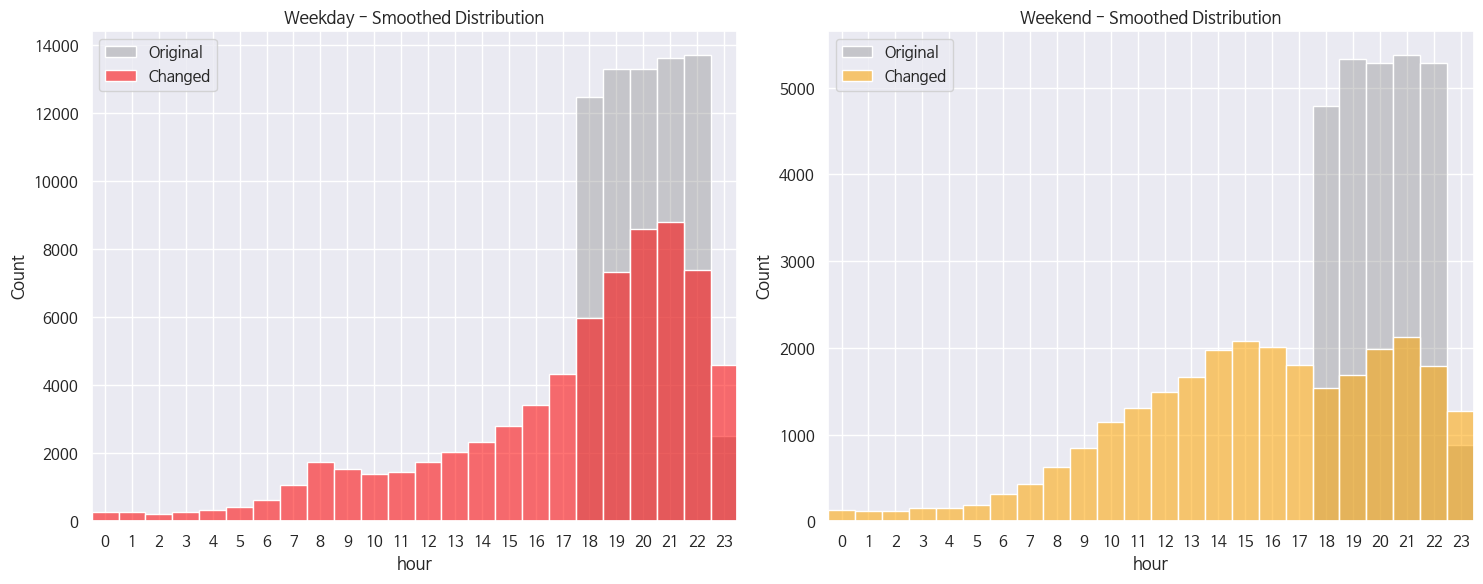

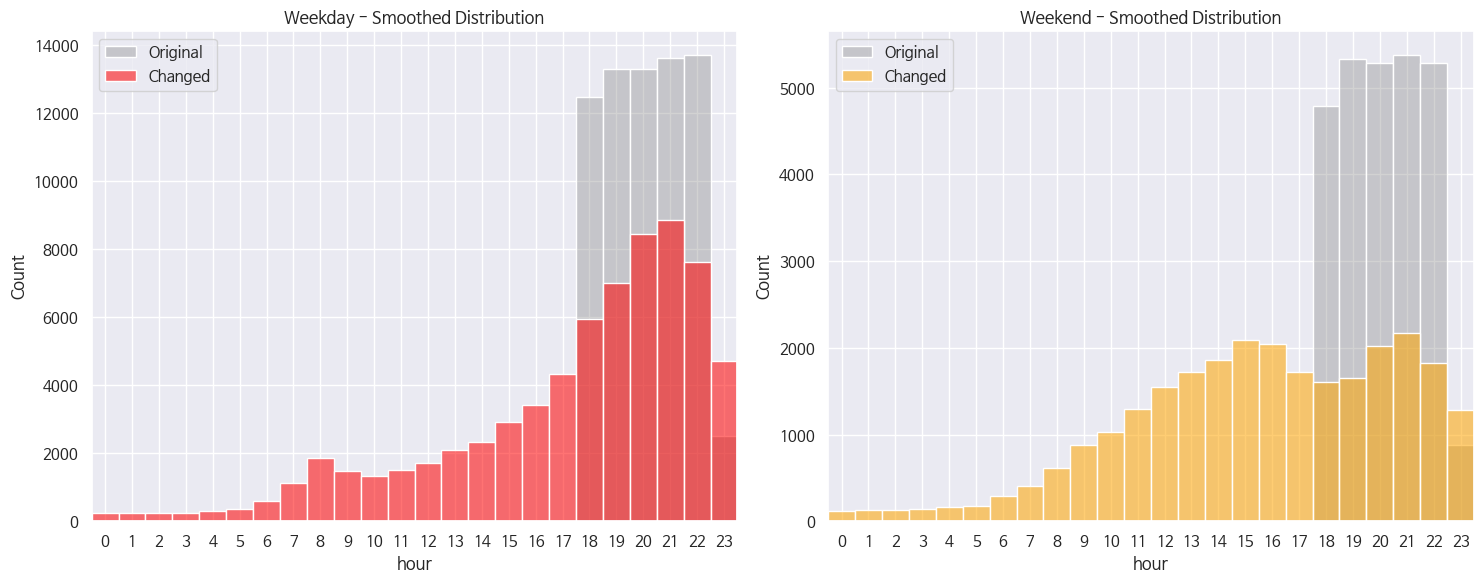

In [16]:
import pandas as pd  # 데이터 처리
import numpy as np  # 수치 계산
import matplotlib.pyplot as plt  # 시각화
import seaborn as sns  # 분포 그래프

# 1. 데이터 로드
file_path = str(WATCH_PATH_DEFAULT)
df_raw = pd.read_csv(file_path)  # watch 로그 불러오기
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])  # timestamp를 날짜형으로 변환

# 2. 비교용
df_before = df_raw.copy()  # 보정 전 데이터
df_after = df_raw.copy()  # 보정 후 데이터

# 3. 시간대 분포 가중치
#    - 모든 시간대에 0이 아닌 값 부여 -> 빈 구간 최소화
#    - 피크타임(평일 20~22시 / 주말 14~16시, 20~22시)은 조금 더 높게
weekday_probs = np.array([
    0.004, 0.004, 0.004, 0.004, 0.005, 0.006,
    0.010, 0.018, 0.028, 0.025, 0.022, 0.024,
    0.028, 0.032, 0.038, 0.045, 0.055, 0.070,
    0.095, 0.115, 0.135, 0.140, 0.120, 0.075
], dtype=float)
weekday_probs /= weekday_probs.sum()

weekend_probs = np.array([
    0.006, 0.006, 0.006, 0.006, 0.007, 0.009,
    0.014, 0.020, 0.030, 0.040, 0.050, 0.060,
    0.070, 0.080, 0.092, 0.100, 0.095, 0.082,
    0.075, 0.082, 0.095, 0.100, 0.085, 0.060
], dtype=float)
weekend_probs /= weekend_probs.sum()

hours = np.arange(24)

def sample_hour(probs):
    return np.random.choice(hours, p=probs)

# 4. 분포 재배치 함수
def apply_fix(row):
    ts = row['timestamp']

    # 주말: 전체를 주말 패턴으로 재분배
    if ts.dayofweek >= 5:
        new_hour = sample_hour(weekend_probs)
        return ts.replace(
            hour=int(new_hour),
            minute=np.random.randint(0, 60),
            second=np.random.randint(0, 60)
        )

    # 평일: 기존 저녁 몰림(18~23시)만 완화해서 자연스럽게 퍼뜨림
    elif 18 <= ts.hour <= 23:
        new_hour = sample_hour(weekday_probs)
        return ts.replace(
            hour=int(new_hour),
            minute=np.random.randint(0, 60),
            second=np.random.randint(0, 60)
        )

    # 그 외 평일 데이터는 유지
    return ts

# 적용
df_after['timestamp'] = df_after.apply(apply_fix, axis=1)

# 5. 시각화용 컬럼
for d in [df_before, df_after]:
    d['hour'] = d['timestamp'].dt.hour
    d['day_type'] = d['timestamp'].dt.dayofweek.map(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 6. 시각화
plt.figure(figsize=(15, 6))
bins = np.arange(-0.5, 24.5, 1)

for i, dtype in enumerate(['Weekday', 'Weekend'], 1):
    plt.subplot(1, 2, i)

    sns.histplot(
        data=df_before[df_before['day_type'] == dtype],
        x='hour',
        bins=bins,
        color='gray',
        alpha=0.35,
        label='Original'
    )

    sns.histplot(
        data=df_after[df_after['day_type'] == dtype],
        x='hour',
        bins=bins,
        color='red' if i == 1 else 'orange',
        alpha=0.55,
        label='Changed'
    )

    plt.title(f'{dtype} - Smoothed Distribution')
    plt.xticks(range(24))
    plt.xlim(-0.5, 23.5)
    plt.legend()

plt.tight_layout()
plt.show()

# 7. 저장
df_after.to_csv(DASHBOARD_WATCH_DISTRIBUTION_PATH, index=False)

# 2. 비교용
df_before = df_raw.copy()  # 보정 전 데이터
df_after = df_raw.copy()  # 보정 후 데이터

# 3. 시간대 분포 가중치
#    - 모든 시간대에 0이 아닌 값 부여 -> 빈 구간 최소화
#    - 피크타임(평일 20~22시 / 주말 14~16시, 20~22시)은 조금 더 높게
weekday_probs = np.array([
    0.004, 0.004, 0.004, 0.004, 0.005, 0.006,
    0.010, 0.018, 0.028, 0.025, 0.022, 0.024,
    0.028, 0.032, 0.038, 0.045, 0.055, 0.070,
    0.095, 0.115, 0.135, 0.140, 0.120, 0.075
], dtype=float)
weekday_probs /= weekday_probs.sum()

weekend_probs = np.array([
    0.006, 0.006, 0.006, 0.006, 0.007, 0.009,
    0.014, 0.020, 0.030, 0.040, 0.050, 0.060,
    0.070, 0.080, 0.092, 0.100, 0.095, 0.082,
    0.075, 0.082, 0.095, 0.100, 0.085, 0.060
], dtype=float)
weekend_probs /= weekend_probs.sum()

hours = np.arange(24)

def sample_hour(probs):
    return np.random.choice(hours, p=probs)

# 4. 분포 재배치 함수
def apply_fix(row):
    ts = row['timestamp']

    # 주말: 전체를 주말 패턴으로 재분배
    if ts.dayofweek >= 5:
        new_hour = sample_hour(weekend_probs)
        return ts.replace(
            hour=int(new_hour),
            minute=np.random.randint(0, 60),
            second=np.random.randint(0, 60)
        )

    # 평일: 기존 저녁 몰림(18~23시)만 완화해서 자연스럽게 퍼뜨림
    elif 18 <= ts.hour <= 23:
        new_hour = sample_hour(weekday_probs)
        return ts.replace(
            hour=int(new_hour),
            minute=np.random.randint(0, 60),
            second=np.random.randint(0, 60)
        )

    # 그 외 평일 데이터는 유지
    return ts

# 적용
df_after['timestamp'] = df_after.apply(apply_fix, axis=1)

# 5. 시각화용 컬럼
for d in [df_before, df_after]:
    d['hour'] = d['timestamp'].dt.hour
    d['day_type'] = d['timestamp'].dt.dayofweek.map(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 6. 시각화
plt.figure(figsize=(15, 6))
bins = np.arange(-0.5, 24.5, 1)  # 시간 단위 히스토그램 정렬

for i, dtype in enumerate(['Weekday', 'Weekend'], 1):
    plt.subplot(1, 2, i)

    sns.histplot(
        data=df_before[df_before['day_type'] == dtype],
        x='hour',
        bins=bins,
        color='gray',
        alpha=0.35,
        label='Original'
    )

    sns.histplot(
        data=df_after[df_after['day_type'] == dtype],
        x='hour',
        bins=bins,
        color='red' if i == 1 else 'orange',
        alpha=0.55,
        label='Changed'
    )

    plt.title(f'{dtype} - Smoothed Distribution')
    plt.xticks(range(24))
    plt.xlim(-0.5, 23.5)
    plt.legend()

plt.tight_layout()
plt.show()

# 7. 저장
df_after.to_csv(DASHBOARD_WATCH_DISTRIBUTION_PATH, index=False)

### Dashboard 구성 요소


In [17]:
dashboard_components = [  # 대시보드 주요 컴포넌트 목록
    "AnalysisPipeline.tsx",
    "ChurnReasonsChart.tsx",
    "ChurnTrendChart.tsx",
    "InterventionQueue.tsx",
    "KPIRow.tsx",
    "RiskDistribution.tsx",
]
print("업로드된 dashboard.zip 컴포넌트:")
for item in dashboard_components:
    print("-", item)

print("\n노트북 산출물 연결:")
print("- dashboard_results_final10_TypeA.csv")
print("- dashboard_results_final10_TypeA_ops.csv")
print("- final10_lightgbm_metrics.csv")
print("- shap_global_importance.csv")
print("- shap_high_risk_top_reasons.csv")
print("- CHECK_THIS_FILE.csv")

업로드된 dashboard.zip 컴포넌트:
- AnalysisPipeline.tsx
- ChurnReasonsChart.tsx
- ChurnTrendChart.tsx
- InterventionQueue.tsx
- KPIRow.tsx
- RiskDistribution.tsx

노트북 산출물 연결:
- dashboard_results_final10_TypeA.csv
- dashboard_results_final10_TypeA_ops.csv
- final10_lightgbm_metrics.csv
- shap_global_importance.csv
- shap_high_risk_top_reasons.csv
- CHECK_THIS_FILE.csv


### 대시보드 연동 산출물 목록

In [18]:
print("최종 산출 파일 확인:")
for p in [  # 최종 산출 파일 존재 여부 확인
    ENRICHED_CHURN_PATH,
    PANEL_PATH,
    METRICS_PATH,
    DASHBOARD_FULL_PATH,
    DASHBOARD_OPS_PATH,
    SHAP_GLOBAL_CSV,
    SHAP_HIGH_RISK_CSV,
    SHAP_HIGH_RISK_TEXT_CSV,
    SHAP_BEESWARM_PNG,
    SHAP_BAR_PNG,
    DASHBOARD_WATCH_DISTRIBUTION_PATH,
]:
    print(f"{p.name}: {'OK' if p.exists() else 'MISSING'}")

최종 산출 파일 확인:
synthetic_churn_final_enriched.csv: MISSING
weekly_snapshot_panel_28d_features_14d_label.csv: OK
final10_lightgbm_metrics.csv: OK
dashboard_results_final10_TypeA.csv: OK
dashboard_results_final10_TypeA_ops.csv: OK
shap_global_importance.csv: OK
shap_high_risk_top_reasons.csv: OK
shap_high_risk_top_reasons_with_text.csv: MISSING
shap_beeswarm_global.png: OK
shap_bar_global.png: OK
CHECK_THIS_FILE.csv: OK
